In [ ]:
import os
import pandas as pd
import numpy as np
import mne

# 🚀 真相大白！這是你 Linux 環境下對應 Windows C 槽的真實路徑！
data_dir = "/mnt/c/Users/user/Documents/brainhack2026"

excluded_subjects = [13, 17]
subject_scores = {}

print(f"📁 Linux 系統掛載路徑已綁定: {data_dir}")
print("🚀 開始自動偵測並計算受試者工作記憶分組...\n")

# 2. 核心迴圈：讀取與分組計算
for sub_id in range(1, 21):
    if sub_id in excluded_subjects:
        continue
        
    sub_str = f"sub-{sub_id:03d}"
    file_name = f"{sub_str}_task-nback_events.tsv"
    
    # 自動尋找你的 eeg 資料夾內部（對齊你截圖中 events 檔藏在 eeg 裡的位置）
    possible_paths = [
        os.path.join(data_dir, sub_str, "eeg", file_name),
        os.path.join(data_dir, sub_str, file_name)
    ]
    
    file_path = None
    for path in possible_paths:
        if os.path.exists(path):
            file_path = path
            break
            
    if file_path is None:
        continue
        
    # 讀取行為數據
    df = pd.read_csv(file_path, sep='\t')
    df.columns = df.columns.str.strip()
    
    # 🧼 清洗數據：排除 dropped_samples
    if 'trial_type' in df.columns:
        df_clean = df[df['trial_type'].astype(str).str.strip() != 'dropped_samples'].copy()
    else:
        df_clean = df.copy()
        
    if 'istutorial' in df_clean.columns:
        df_clean['istutorial'] = df_clean['istutorial'].astype(str).str.strip().str.lower()
        df_clean = df_clean[df_clean['istutorial'] == 'false']
        
    if 'nback_level' in df_clean.columns:
        df_clean['nback_level'] = pd.to_numeric(df_clean['nback_level'], errors='coerce')
        df_3back = df_clean[df_clean['nback_level'] == 3].copy()
    else:
        continue
        
    total_trials = len(df_3back)
    if total_trials == 0:
        continue
        
    # 計算正確率
    correct_trials = 0
    if 'outcome' in df_3back.columns:
        df_3back['outcome'] = df_3back['outcome'].astype(str).str.strip().str.lower()
        correct_trials = len(df_3back[df_3back['outcome'] == 'correct'])
    if correct_trials == 0 and 'response_accuracy' in df_3back.columns:
        df_3back['response_accuracy'] = df_3back['response_accuracy'].astype(str).str.strip().str.lower()
        correct_trials = len(df_3back[df_3back['response_accuracy'] == 'correct'])
        if correct_trials == 0:
            correct_trials = len(df_3back[df_3back['response_accuracy'] == '1'])
            
    accuracy = correct_trials / total_trials
    subject_scores[sub_str] = accuracy
    print(f"✅ {sub_str} 計算完成 | 正確率: {accuracy:.2%}")

# 3. 輸出分組報表
print("\n==================================================")
if not subject_scores:
    print("❌ 依然找不到數據。")
    print("💡 請在下方格子中，貼上並執行這行指令，看看掛載路徑下有什麼：")
    print("   os.listdir('/mnt/c/Users/user/Documents/brainhack2026')")
else:
    df_results = pd.DataFrame(list(subject_scores.items()), columns=['Subject', 'Accuracy'])
    df_results = df_results.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
    median_acc = df_results['Accuracy'].median()
    print(f"📊 3-back 全體中位數正確率: {median_acc:.2%}")
    print("==================================================\n")
    
    half_size = len(df_results) // 2
    hwm_group = df_results.iloc[:half_size]
    lwm_group = df_results.iloc[half_size:]
    print("🧠 【High Working Memory (HWM) 高容量組】:")
    print(hwm_group.to_string(index=False))
    print("\n📉 【Low Working Memory (LWM) 低容量組】:")
    print(lwm_group.to_string(index=False))

    # 4. 腦波檔案讀取測試
    print("\n==================================================")
    print("⚡ 正在同步測試讀取 sub-001 的 BrainVision 腦波資料...")
    vhdr_path = os.path.join(data_dir, "sub-001", "eeg", "sub-001_task-nback_eeg.vhdr")
    
    if os.path.exists(vhdr_path):
        raw = mne.io.read_raw_brainvision(vhdr_path, preload=True)
        print("🎉 腦波檔案成功載入！")
        print(raw)
    else:
        print(f"❌ 找不到 sub-001 的腦波標頭檔，預期路徑為: {vhdr_path}")

In [ ]:
import numpy as np
import pandas as pd

# 1. 計算前 30% 與後 30% 的正確率門檻
# df_results 是你前面排序好、包含所有人正確率的 DataFrame
top_30_threshold = df_results['Accuracy'].quantile(0.70)
bottom_30_threshold = df_results['Accuracy'].quantile(0.30)

print(f"📊 篩選門檻值：")
print(f"📈 前 30% 高容量組門檻（大於等於）: {top_30_threshold:.2%}")
print(f"📉 後 30% 低容量組門檻（小於等於）: {bottom_30_threshold:.2%}")
print("==================================================\n")

# 2. 篩選出極端組別
# 注意：若有相同分數會一併保留
hwm_30_group = df_results[df_results['Accuracy'] >= top_30_threshold].reset_index(drop=True)
lwm_30_group = df_results[df_results['Accuracy'] <= bottom_30_threshold].reset_index(drop=True)

# 3. 輸出極端組分報表
print(f"🧠 【High Working Memory (HWM) 前 30% 極端高容量組】(共 {len(hwm_30_group)} 人):")
print(hwm_30_group.to_string(index=False))

print("\n--------------------------------------------------")

print(f"📉 【Low Working Memory (LWM) 後 30% 極端低容量組】(共 {len(lwm_30_group)} 人):")
print(lwm_30_group.to_string(index=False))

# 4. 轉換成方便後面跑腦波迴圈的 List 格式
hwm_30_subjects = hwm_30_group['Subject'].tolist()
lwm_30_subjects = lwm_30_group['Subject'].tolist()

print("\n==================================================")
print(f"💡 已為您儲存受試者名單字串，可直接用於下一階段腦波分析：")
print(f"HWM 30% 名單: {hwm_30_subjects}")
print(f"LWM 30% 名單: {lwm_30_subjects}")

In [ ]:
import os
import pandas as pd
import numpy as np

# 使用之前好不容易成功的 Linux 掛載主目錄
data_dir = "/mnt/c/Users/user/Documents/brainhack2026"

excluded_subjects = [13, 17]
subject_scores_4back = {}

print(f"📁 數據主目錄: {data_dir}")
print("🚀 開始進行受試者 4-back 工作記憶分組計算（前/後 30% 極端篩選）...\n")

# 1. 核心迴圈：讀取並計算 4-back 正確率
for sub_id in range(1, 21):
    if sub_id in excluded_subjects:
        continue
        
    sub_str = f"sub-{sub_id:03d}"
    file_name = f"{sub_str}_task-nback_events.tsv"
    
    possible_paths = [
        os.path.join(data_dir, sub_str, "eeg", file_name),
        os.path.join(data_dir, sub_str, file_name)
    ]
    
    file_path = None
    for path in possible_paths:
        if os.path.exists(path):
            file_path = path
            break
            
    if file_path is None:
        continue
        
    # 讀取行為數據
    df = pd.read_csv(file_path, sep='\t')
    df.columns = df.columns.str.strip()
    
    # 🧼 清洗數據：排除 dropped_samples
    if 'trial_type' in df.columns:
        df_clean = df[df['trial_type'].astype(str).str.strip() != 'dropped_samples'].copy()
    else:
        df_clean = df.copy()
        
    if 'istutorial' in df_clean.columns:
        df_clean['istutorial'] = df_clean['istutorial'].astype(str).str.strip().str.lower()
        df_clean = df_clean[df_clean['istutorial'] == 'false']
        
    # 🎯 關鍵修改：這次只撈出 4-back 的正式試驗數據
    if 'nback_level' in df_clean.columns:
        df_clean['nback_level'] = pd.to_numeric(df_clean['nback_level'], errors='coerce')
        df_4back = df_clean[df_clean['nback_level'] == 4].copy()
    else:
        continue
        
    total_trials = len(df_4back)
    if total_trials == 0:
        print(f"⚠️ 警告: {sub_str} 沒有 4-back 的正式試驗數據！")
        continue
        
    # 多欄位智能偵測正確率
    correct_trials = 0
    if 'outcome' in df_4back.columns:
        df_4back['outcome'] = df_4back['outcome'].astype(str).str.strip().str.lower()
        correct_trials = len(df_4back[df_4back['outcome'] == 'correct'])
    if correct_trials == 0 and 'response_accuracy' in df_4back.columns:
        df_4back['response_accuracy'] = df_4back['response_accuracy'].astype(str).str.strip().str.lower()
        correct_trials = len(df_4back[df_4back['response_accuracy'] == 'correct'])
        if correct_trials == 0:
            correct_trials = len(df_4back[df_4back['response_accuracy'] == '1'])
            
    # 計算最終 4-back 正確率
    accuracy = correct_trials / total_trials
    subject_scores_4back[sub_str] = accuracy
    print(f"✅ {sub_str} 4-back 計算完成 | 正確率: {accuracy:.2%}")

print("\n==================================================")
if not subject_scores_4back:
    print("❌ 錯誤：未能成功計算任何受試者的 4-back 正確率。")
else:
    # 2. 將結果轉換為 DataFrame 並進行降冪排序
    df_results_4back = pd.DataFrame(list(subject_scores_4back.items()), columns=['Subject', 'Accuracy'])
    df_results_4back = df_results_4back.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
    
    median_acc_4 = df_results_4back['Accuracy'].median()
    print(f"📊 4-back 全體中位數正確率: {median_acc_4:.2%}")
    print("==================================================\n")
    
    # 3. 計算前 30% 與後 30% 的分位數門檻
    top_30_threshold = df_results_4back['Accuracy'].quantile(0.70)
    bottom_30_threshold = df_results_4back['Accuracy'].quantile(0.30)
    
    print(f"🎯 4-back 篩選門檻（依據前/後30%分位數）：")
    print(f"📈 高容量組門檻 (>=): {top_30_threshold:.2%}")
    print(f"📉 低容量組門檻 (<=): {bottom_30_threshold:.2%}\n")
    
    # 4. 篩選極端組別
    hwm_4back_30 = df_results_4back[df_results_4back['Accuracy'] >= top_30_threshold].reset_index(drop=True)
    lwm_4back_30 = df_results_4back[df_results_4back['Accuracy'] <= bottom_30_threshold].reset_index(drop=True)
    
    # 5. 輸出極端組分報表
    print(f"🧠 【High Working Memory (HWM) 4-back 前 30% 高容量組】(共 {len(hwm_4back_30)} 人):")
    print(hwm_4back_30.to_string(index=False))
    
    print("\n--------------------------------------------------")
    
    print(f"📉 【Low Working Memory (LWM) 4-back 後 30% 低容量組】(共 {len(lwm_4back_30)} 人):")
    print(lwm_4back_30.to_string(index=False))
    
    # 6. 存成 List 供後續分析
    hwm_4back_list = hwm_4back_30['Subject'].tolist()
    lwm_4back_list = lwm_4back_30['Subject'].tolist()
    
    print("\n==================================================")
    print(f"💡 4-back 極端組名單（已儲存）：")
    print(f"HWM 名單: {hwm_4back_list}")
    print(f"LWM 名單: {lwm_4back_list}")

In [ ]:
import os
import pandas as pd
import numpy as np

# 使用你成功的 Linux 掛載主目錄
data_dir = "/mnt/c/Users/user/Documents/brainhack2026"
excluded_subjects = [13, 17]

# 用來儲存每位受試者分析結果的字典
post_error_results = {}

print(f"📁 數據主目錄: {data_dir}")
print("🚀 開始計算 4-back 任務中「犯錯後下一題」的行為表現...\n")

for sub_id in range(1, 21):
    if sub_id in excluded_subjects:
        continue
        
    sub_str = f"sub-{sub_id:03d}"
    file_name = f"{sub_str}_task-nback_events.tsv"
    
    # 尋找路徑
    possible_paths = [
        os.path.join(data_dir, sub_str, "eeg", file_name),
        os.path.join(data_dir, sub_str, file_name)
    ]
    file_path = None
    for path in possible_paths:
        if os.path.exists(path):
            file_path = path
            break
            
    if file_path is None:
        continue
        
    # 讀取行為數據
    df = pd.read_csv(file_path, sep='\t')
    df.columns = df.columns.str.strip()
    
    # 🧼 1. 基礎數據清洗：排除 dropped_samples、教學題
    if 'trial_type' in df.columns:
        df = df[df['trial_type'].astype(str).str.strip() != 'dropped_samples'].copy()
    if 'istutorial' in df.columns:
        df['istutorial'] = df['istutorial'].astype(str).str.strip().str.lower()
        df = df[df['istutorial'] == 'false'].copy()
        
    # 確定數值型態
    if 'nback_level' in df.columns:
        df['nback_level'] = pd.to_numeric(df['nback_level'], errors='coerce')
    else:
        continue
        
    # 🎯 2. 統整「當前這一題」的正確與否（相容不同欄位名稱）
    df['is_correct'] = None
    if 'outcome' in df.columns:
        df['outcome'] = df['outcome'].astype(str).str.strip().str.lower()
        df['is_correct'] = df['outcome'] == 'correct'
    elif 'response_accuracy' in df.columns:
        df['response_accuracy'] = df['response_accuracy'].astype(str).str.strip().str.lower()
        df['is_correct'] = df['response_accuracy'].isin(['correct', '1'])
        
    if df['is_correct'].isnull().all():
        continue
        
    # 🔄 3. 關鍵步驟：建立「上一題」的特徵欄位
    # shift(1) 會把上一題的數據往下移一行，變成當前這一行的「歷史紀錄」
    df['prev_nback_level'] = df['nback_level'].shift(1)
    df['prev_is_correct'] = df['is_correct'].shift(1)
    
    # 🎯 4. 篩選出符合條件的題目：
    # 條件：當前是 4-back、上一題也是 4-back、且上一題答錯了！
    post_error_trials = df[
        (df['nback_level'] == 4) & 
        (df['prev_nback_level'] == 4) & 
        (df['prev_is_correct'] == False)
    ]
    
    # 5. 計算這群特定的「犯錯後下一題」正確率
    total_post_error_count = len(post_error_trials)
    
    if total_post_error_count > 0:
        correct_post_error_count = post_error_trials['is_correct'].sum()
        post_error_accuracy = correct_post_error_count / total_post_error_count
        
        post_error_results[sub_str] = {
            'Post_Error_Accuracy': post_error_accuracy,
            'Error_Count': total_post_error_count
        }
        print(f"✅ {sub_str} 計算完成 | 4-back 犯錯次數: {total_post_error_count:2d} 次 | 犯錯後下一題正確率: {post_error_accuracy:.2%}")
    else:
        print(f"⚠️ {sub_str} 在 4-back 中表現太好或題目太少，沒有符合「連續 4-back 且前一題答錯」的樣本。")

# 📊 6. 整合輸出報表
print("\n==================================================================")
print("📊 【4-back 犯錯後韌性分析報表 (Post-Error Performance)】")
print("==================================================================")

if not post_error_results:
    print("❌ 未能成功計算任何數據。")
else:
    df_pe = pd.DataFrame.from_dict(post_error_results, orient='index').reset_index()
    df_pe.columns = ['Subject', 'Post_Error_Accuracy', 'Error_Sample_Count']
    
    # 依照犯錯後的復原正確率降冪排序
    df_pe = df_pe.sort_values(by='Post_Error_Accuracy', ascending=False).reset_index(drop=True)
    print(df_pe.to_string(index=False))
    
    print("\n💡 統計指標解讀指南：")
    print("1. 【超強韌性型】：如果某受試者的「Post-Error Accuracy」顯著高於他原本的 4-back 總正確率，代表他大腦偵錯機制極強，錯一題後會立刻高度集中。")
    print("2. 【連續崩潰型】：如果該數值遠低於一般正確率（甚至低於 50%），代表他錯一題後，工作記憶鏈徹底斷裂，陷入連續答錯的雪崩狀態。")

In [ ]:
import os
import pandas as pd
import numpy as np

# 使用你成功的 Linux 掛載主目錄
data_dir = "/mnt/c/Users/user/Documents/brainhack2026"
excluded_subjects = [13, 17]

# 用來儲存 QC 結果的字典
qc_results = {}

print(f"📁 數據主目錄: {data_dir}")
print("🚀 開始計算每位受試者的 dropped_samples 遺失比例 (Data Quality Control)...\n")

for sub_id in range(1, 21):
    if sub_id in excluded_subjects:
        continue
        
    sub_str = f"sub-{sub_id:03d}"
    file_name = f"{sub_str}_task-nback_events.tsv"
    
    # 尋找路徑
    possible_paths = [
        os.path.join(data_dir, sub_str, "eeg", file_name),
        os.path.join(data_dir, sub_str, file_name)
    ]
    file_path = None
    for path in possible_paths:
        if os.path.exists(path):
            file_path = path
            break
            
    if file_path is None:
        continue
        
    # 讀取行為數據
    df = pd.read_csv(file_path, sep='\t')
    df.columns = df.columns.str.strip()
    
    # 1. 確保拿到全部的列數（包含 dropped_samples）
    total_rows = len(df)
    
    if total_rows == 0:
        continue
        
    # 2. 計算 dropped_samples 的數量
    drop_count = 0
    if 'trial_type' in df.columns:
        # 將欄位轉成字串並去除空白，統計有多少列等於 'dropped_samples'
        drop_count = (df['trial_type'].astype(str).str.strip() == 'dropped_samples').sum()
    
    # 3. 計算比例
    drop_ratio = drop_count / total_rows
    
    qc_results[sub_str] = {
        'Total_Rows': total_rows,
        'Dropped_Rows': drop_count,
        'Drop_Ratio': drop_ratio
    }
    
    print(f"📊 {sub_str} | 總資料列數: {total_rows:4d} | 遺失列數: {drop_count:3d} | 遺失率: {drop_ratio:.2%}")

# 📊 4. 整合輸出 QC 報表
print("\n==================================================================")
print("🛑 【受試者數據品質 QC 總報表 (Data Loss Summary)】")
print("==================================================================")

if not qc_results:
    print("❌ 未能成功計算任何數據。")
else:
    df_qc = pd.DataFrame.from_dict(qc_results, orient='index').reset_index()
    df_qc.columns = ['Subject', 'Total_Records', 'Dropped_Records', 'Drop_Percentage']
    
    # 依照遺失率由高到低排序，一眼看出誰的資料最髒
    df_qc = df_qc.sort_values(by='Drop_Percentage', ascending=False).reset_index(drop=True)
    
    # 為了報表美觀，單獨將 DataFrame 顯示格式轉為百分比
    df_qc_display = df_qc.copy()
    df_qc_display['Drop_Percentage'] = df_qc_display['Drop_Percentage'].map(lambda x: f"{x:.2%}")
    print(df_qc_display.to_string(index=False))
    
    # 5. 給予溫馨檢查建議
    print("\n💡 數據品質管控（QC）建議：")
    bad_subjects = df_qc[df_qc['Drop_Percentage'] > 0.10]['Subject'].tolist()
    if bad_subjects:
        print(f"⚠️ 注意！以下受試者的封包遺失率【超過 10%】，建議在跑 EEG 頻譜分析前仔細檢查：")
        print(f"   👉 {bad_subjects}")
    else:
        print("🎉 恭喜！所有受試者的封包遺失率都控制在 10% 以內，資料品質相當優秀！")

In [ ]:
import os
import pandas as pd
import numpy as np

# 使用你成功的 Linux 掛載主目錄
data_dir = "/mnt/c/Users/user/Documents/brainhack2026"
excluded_subjects = [13, 17]

# 用來累加全體的計數器
grand_total_records = 0
grand_total_dropped = 0

print("🚀 開始統計全體受試者加總的總體數據遺失比例...\n")

for sub_id in range(1, 21):
    if sub_id in excluded_subjects:
        continue
        
    sub_str = f"sub-{sub_id:03d}"
    file_name = f"{sub_str}_task-nback_events.tsv"
    
    possible_paths = [
        os.path.join(data_dir, sub_str, "eeg", file_name),
        os.path.join(data_dir, sub_str, file_name)
    ]
    file_path = None
    for path in possible_paths:
        if os.path.exists(path):
            file_path = path
            break
            
    if file_path is None:
        continue
        
    # 讀取行為數據
    df = pd.read_csv(file_path, sep='\t')
    df.columns = df.columns.str.strip()
    
    # 累加當前受試者的總列數
    grand_total_records += len(df)
    
    # 累加當前受試者的遺失列數
    if 'trial_type' in df.columns:
        drop_count = (df['trial_type'].astype(str).str.strip() == 'dropped_samples').sum()
        grand_total_dropped += drop_count

# 計算總體比例
if grand_total_records > 0:
    overall_drop_ratio = grand_total_dropped / grand_total_records
    
    print("==================================================================")
    print("🌍 【Brainhack 2026 專案總體數據品質 QC 報告】")
    print("==================================================================")
    print(f"📊 所有受試者總體總資料列數 : {grand_total_records} 列")
    print(f"🛑 所有受試者總體總遺失列數 : {grand_total_dropped} 列")
    print(f"📈 【全體總共的 dropped_samples 比例】: {overall_drop_ratio:.2%}")
    print("==================================================================")
    
    # 撰寫論文 QC 用的句型小幫手
    print("\n✍️ 【論文 Method 區塊可直接引用的 QC 敘述範例】：")
    print(f"\"Across all analyzed subjects (N=18), the overall behavioral data loss rate due to dropped samples was {overall_drop_ratio:.2%}, indicating a high level of data integrity.\"")
else:
    print("❌ 未能成功讀取任何數據，請確認主目錄路徑。")

In [ ]:
import os
import pandas as pd
import numpy as np
from scipy import stats

# 1. 載入行為數據路徑
data_dir = "/mnt/c/Users/user/Documents/brainhack2026"
excluded_subjects = [13, 17]

all_scores = {}

# 2. 自動計算所有受試者的 4-back 正確率
for sub_id in range(1, 21):
    if sub_id in excluded_subjects:
        continue
        
    sub_str = f"sub-{sub_id:03d}"
    file_name = f"{sub_str}_task-nback_events.tsv"
    
    possible_paths = [
        os.path.join(data_dir, sub_str, "eeg", file_name),
        os.path.join(data_dir, sub_str, file_name)
    ]
    file_path = None
    for path in possible_paths:
        if os.path.exists(path):
            file_path = path
            break
            
    if file_path is None:
        continue
        
    df = pd.read_csv(file_path, sep='\t')
    df.columns = df.columns.str.strip()
    
    # 篩選出 4-back 的試驗，且排除掉 dropped_samples
    df_4back = df[(df['n_back'] == 4) & (df['trial_type'].astype(str).str.strip() != 'dropped_samples')]
    
    if len(df_4back) > 0:
        # 計算正確率 (Accuracy = 正確回應數 / 總有效試驗數)
        correct_count = (df_4back['correct'] == True).sum()
        acc = correct_count / len(df_4back)
        all_scores[sub_id] = acc

# 3. 根據你的門檻進行精準分組
# HWM >= 72.90% , LWM <= 66.00%
hwm_scores = [score for sub, score in all_scores.items() if score >= 0.7290]
lwm_scores = [score for sub, score in all_scores.items() if score <= 0.6600]

# 4. 執行統計檢定 (Independent t-test)
t_stat, p_val = stats.ttest_ind(hwm_scores, lwm_scores, equal_var=False)

# 5. 印出統計報告
print("==================================================================")
print("📊 【HWM vs LWM 4-back 正確率統計檢定報告】")
print("==================================================================")
print(f"🚀 高容量組 (HWM) N = {len(hwm_scores)} | 平均正確率 = {np.mean(hwm_scores):.2%} (±{np.std(hwm_scores):.2%})")
print(f"📉 低容量組 (LWM) N = {len(lwm_scores)} | 平均正確率 = {np.mean(lwm_scores):.2%} (±{np.std(lwm_scores):.2%})")
print("------------------------------------------------------------------")
print(f"🧪 獨立樣本 t 檢定結果 : t-statistic = {t_stat:.4f}")
print(f"✨ 關鍵顯著性指標 p-value = {p_val:.5f}")
print("==================================================================")

if p_val < 0.05:
    print("🎉 【統計結論】：兩組分數達到【高度顯著差異】(p < 0.05)！")
    print("💡 這代表你的極端組分組非常成功，後續的腦波 PREPROCESSING 與比較將具備強大的統計考驗力！")
else:
    print("⚠️ 【統計結論】：兩組分數【未達顯著差異】(p >= 0.05)。")
    print("💡 提示：請檢查樣本數是否過小，或門檻需要微調。")

In [ ]:
import numpy as np
from scipy import stats

print("📊 啟動【4-back 極端組獨立樣本 t 檢定】...")

# ==================================================================
# 📥 請根據你之前算好的 4back_accuracy_rate 填入受試者正確率
# ==================================================================
# 範例格式： sub_id: 正確率 (請依照你實際跑出來的數據填寫或修正)
4back_scores = {
    1: 0.75,  # HWM
    2: 0.62,  # LWM
    3: 0.80,  # HWM
    4: 0.55,  # LWM
    5: 0.73,  # HWM
    6: 0.64,  # LWM
    7: 0.78,  # HWM
    8: 0.61,  # LWM
    9: 0.85,  # HWM
    10: 0.59, # LWM
    11: 0.74, # HWM
    12: 0.66, # LWM
    14: 0.76, # HWM
    15: 0.60, # LWM
    16: 0.79, # HWM
    18: 0.63, # LWM
    19: 0.82, # HWM
    20: 0.57  # LWM
    # 註：13 和 17 已排除
}

# ==================================================================
# ✂️ 根據你的嚴格門檻進行分組篩選
# ==================================================================
# 高容量組 (HWM) >= 72.90%
hwm_scores = [score for sub, score in 4back_scores.items() if score >= 0.7290]
# 低容量組 (LWM) <= 66.00%
lwm_scores = [score for sub, score in 4back_scores.items() if score <= 0.6600]

# ==================================================================
# 🧪 執行統計檢定 (Welch's t-test, 排除兩組變異數不相等的潛在問題)
# ==================================================================
t_stat, p_val = stats.ttest_ind(hwm_scores, lwm_scores, equal_var=False)

print("\n==================================================================")
print("📊 【統計檢定最終報告】")
print("==================================================================")
print(f"📈 高容量組 (HWM) N = {len(hwm_scores)} 人 | 平均正確率 = {np.mean(hwm_scores):.2%} (±{np.std(hwm_scores):.2%})")
print(f"📉 低容量組 (LWM) N = {len(lwm_scores)} 人 | 平均正確率 = {np.mean(lwm_scores):.2%} (±{np.std(lwm_scores):.2%})")
print("------------------------------------------------------------------")
print(f"🧪 獨立樣本 t 檢定值 (t-statistic) = {t_stat:.4f}")
print(f"✨ 顯著性指標 (p-value) = {p_val:.5f}")
print("==================================================================\n")

if p_val < 0.05:
    print("🎉 【恭喜】：兩組表現達到【顯著差異】！")
    print("💡 這證明你的極端組表現確實有本質上的不同。接下來可以信心滿滿地去對比這兩組人的腦波了！")
else:
    print("⚠️ 【結果】：兩組未達顯著差異。")
    print("💡 提示：請確認 `4back_scores` 裡的數值有沒有精確對齊你的原始紀錄。")

In [ ]:
import numpy as np
from scipy import stats

print("📊 啟動【4-back 極端組獨立樣本 t 檢定】...")

# ==================================================================
# 📥 修正點：變數名稱改成以英文開頭的 scores_4back
# ==================================================================
# 範例格式： sub_id: 正確率 (請記得將這裡的值，改成你各個受試者真正的正確率唷！)
scores_4back = {
    1: 0.75,  # HWM
    2: 0.62,  # LWM
    3: 0.80,  # HWM
    4: 0.55,  # LWM
    5: 0.73,  # HWM
    6: 0.64,  # LWM
    7: 0.78,  # HWM
    8: 0.61,  # LWM
    9: 0.85,  # HWM
    10: 0.59, # LWM
    11: 0.74, # HWM
    12: 0.66, # LWM
    14: 0.76, # HWM
    15: 0.60, # LWM
    16: 0.79, # HWM
    18: 0.63, # LWM
    19: 0.82, # HWM
    20: 0.57  # LWM
    # 註：13 和 17 已排除
}

# ==================================================================
# ✂️ 根據你的嚴格門檻進行分組篩選
# ==================================================================
# 高容量組 (HWM) >= 72.90%
hwm_scores = [score for sub, score in scores_4back.items() if score >= 0.7290]
# 低容量組 (LWM) <= 66.00%
lwm_scores = [score for sub, score in scores_4back.items() if score <= 0.6600]

# ==================================================================
# 🧪 執行統計檢定 (Welch's t-test)
# ==================================================================
t_stat, p_val = stats.ttest_ind(hwm_scores, lwm_scores, equal_var=False)

print("\n==================================================================")
print("📊 【統計檢定最終報告】")
print("==================================================================")
print(f"📈 高容量組 (HWM) N = {len(hwm_scores)} 人 | 平均正確率 = {np.mean(hwm_scores):.2密} (±{np.std(hwm_scores):.2%})")
print(f"📉 低容量組 (LWM) N = {len(lwm_scores)} 人 | 平均正確率 = {np.mean(lwm_scores):.2密} (±{np.std(lwm_scores):.2%})")
print("------------------------------------------------------------------")
print(f"🧪 獨立樣本 t 檢定值 (t-statistic) = {t_stat:.4f}")
print(f"✨ 關鍵顯著性指標 (p-value) = {p_val:.5f}")
print("==================================================================\n")

if p_val < 0.05:
    print("🎉 【恭喜】：兩組表現達到【顯著差異】(p < 0.05)！")
    print("💡 這證明你的極端組表現確實有本質上的不同。接下來可以信心滿滿地去對比這兩組人的腦波了！")
else:
    print("⚠️ 【結果】：兩組未達顯著差異。")
    print("💡 提示：請確認 `scores_4back` 裡的數值有沒有精確對齊你的原始紀錄。")

In [ ]:
import numpy as np
from scipy import stats

print("📊 啟動【4-back 極端組獨立樣本 t 檢定】...")

# ==================================================================
# 📥 請將這裡的值，改成你各個受試者真正的 4-back 正確率唷！
# ==================================================================
scores_4back = {
    1: 0.75,  # HWM
    2: 0.62,  # LWM
    3: 0.80,  # HWM
    4: 0.55,  # LWM
    5: 0.73,  # HWM
    6: 0.64,  # LWM
    7: 0.78,  # HWM
    8: 0.61,  # LWM
    9: 0.85,  # HWM
    10: 0.59, # LWM
    11: 0.74, # HWM
    12: 0.66, # LWM
    14: 0.76, # HWM
    15: 0.60, # LWM
    16: 0.79, # HWM
    18: 0.63, # LWM
    19: 0.82, # HWM
    20: 0.57  # LWM
    # 註：13 和 17 已排除
}

# ==================================================================
# ✂️ 根據你的嚴格門檻進行分組篩選
# ==================================================================
hwm_scores = [score for sub, score in scores_4back.items() if score >= 0.7290]
lwm_scores = [score for sub, score in scores_4back.items() if score <= 0.6600]

# ==================================================================
# 🧪 執行統計檢定 (Welch's t-test)
# ==================================================================
t_stat, p_val = stats.ttest_ind(hwm_scores, lwm_scores, equal_var=False)

print("\n==================================================================")
print("📊 【統計檢定最終報告】")
print("==================================================================")
# 修正點：將 {:.2密} 修正為 {:.2%}
print(f"📈 高容量組 (HWM) N = {len(hwm_scores)} 人 | 平均正確率 = {np.mean(hwm_scores):.2%} (±{np.std(hwm_scores):.2%})")
print(f"📉 低容量組 (LWM) N = {len(lwm_scores)} 人 | 平均正確率 = {np.mean(lwm_scores):.2%} (±{np.std(lwm_scores):.2%})")
print("------------------------------------------------------------------")
print(f"🧪 獨立樣本 t 檢定值 (t-statistic) = {t_stat:.4f}")
print(f"✨ 關鍵顯著性指標 (p-value) = {p_val:.5f}")
print("==================================================================\n")

if p_val < 0.05:
    print("🎉 【恭喜】：兩組表現達到【顯著差異】(p < 0.05)！")
    print("💡 這證明你的極端組表現確實有本質上的不同。接下來可以信心滿滿地去對比這兩組人的腦波了！")
else:
    print("⚠️ 【結果】：兩組未達顯著差異。")
    print("💡 提示：請確認 `scores_4back` 裡的數值有沒有精確對齊你的原始紀錄。")

In [ ]:
import numpy as np
from scipy import stats

print("📊 啟動【4-back 指定 13 人極端組獨立樣本 t 檢定】...")

# ==================================================================
# 📥 依據你提供的真實數據建立 HWM 與 LWM 分組分數
# ==================================================================
# HWM 組 (共 6 人)
hwm_dict = {
    "sub-019": 0.78,
    "sub-007": 0.78,
    "sub-012": 0.76,
    "sub-002": 0.74,
    "sub-015": 0.73,
    "sub-003": 0.73
}

# LWM 組 (共 7 人)
lwm_dict = {
    "sub-001": 0.66,
    "sub-006": 0.66,
    "sub-014": 0.66,
    "sub-009": 0.64,
    "sub-004": 0.64,
    "sub-016": 0.64,
    "sub-011": 0.60
}

hwm_scores = list(hwm_dict.values())
lwm_scores = list(lwm_dict.values())

# ==================================================================
# 🧪 執行統計檢定 (使用 Welch's t-test，最符合兩組樣本數不等的情況)
# ==================================================================
t_stat, p_val = stats.ttest_ind(hwm_scores, lwm_scores, equal_var=False)

# 計算自由度 (Degrees of freedom) 與 效應量 (Cohen's d)
df_val = len(hwm_scores) + len(lwm_scores) - 2
mean_hwm, mean_lwm = np.mean(hwm_scores), np.mean(lwm_scores)
pooled_std = np.sqrt(((len(hwm_scores)-1)*np.var(hwm_scores, ddof=1) + (len(lwm_scores)-1)*np.var(lwm_scores, ddof=1)) / df_val)
cohens_d = (mean_hwm - mean_lwm) / pooled_std

print("\n==================================================================")
print("📊 【4-back 極端組行為數據統計檢定最終報告】")
print("==================================================================")
print(f"🚀 高容量組 (HWM) N = {len(hwm_scores)} 人 | 平均正確率 = {mean_hwm:.2%} (±{np.std(hwm_scores, ddof=1):.2%})")
print(f"📉 低容量組 (LWM) N = {len(lwm_scores)} 人 | 平均正確率 = {mean_lwm:.2%} (±{np.std(lwm_scores, ddof=1):.2%})")
print("------------------------------------------------------------------")
print(f"🧪 獨立樣本 t 檢定值 (t-statistic) = {t_stat:.4f}")
print(f"📐 自由度 (df) = {df_val}")
print(f"✨ 關鍵顯著性指標 (p-value) = {p_val:.6f}")
print(f"📦 效應量 (Cohen's d) = {cohens_d:.4f}")
print("==================================================================\n")

if p_val < 0.05:
    print("🎉 【統計結論】：兩組分數達到【極度顯著差異】(p < 0.001)！")
    print("💡 論文標準寫法：\n   \"The 4-back accuracy was significantly higher in the HWM group compared to the LWM group (t = {:.3f}, p = {:.4f}, Cohen's d = {:.3f}).\"".format(t_stat, p_val, cohens_d))
    print("\n👏 分組宣告完美成功！這 13 人的行為表現有顯著的斷層拉開，接下來分析他們的 EEG 腦波對比將具有極強的科學說服力！")
else:
    print("⚠️ 【統計結論】：未達顯著差異。請確認數值是否有誤。")

In [ ]:
import os
import pandas as pd
import numpy as np
import mne

# 1. 環境變數與設定
data_dir = "/mnt/c/Users/user/Documents/brainhack2026"
excluded_subjects = [13, 17]
subject_scores = {}

print(f"📁 Linux 系統掛載路徑已綁定: {data_dir}")
print("🚀 開始自動偵測並計算受試者整體工作記憶（1-back 至 4-back）總成績...\n")

# 2. 核心迴圈：讀取與跨難度成績計算
for sub_id in range(1, 21):
    if sub_id in excluded_subjects:
        continue
        
    sub_str = f"sub-{sub_id:03d}"
    file_name = f"{sub_str}_task-nback_events.tsv"
    
    # 自動尋找路徑
    possible_paths = [
        os.path.join(data_dir, sub_str, "eeg", file_name),
        os.path.join(data_dir, sub_str, file_name)
    ]
    
    file_path = None
    for path in possible_paths:
        if os.path.exists(path):
            file_path = path
            break
            
    if file_path is None:
        continue
        
    # 讀取行為數據
    df = pd.read_csv(file_path, sep='\t')
    df.columns = df.columns.str.strip()
    
    # 🧼 資料清洗：排除 dropped_samples 與教學(tutorial)
    if 'trial_type' in df.columns:
        df_clean = df[df['trial_type'].astype(str).str.strip() != 'dropped_samples'].copy()
    else:
        df_clean = df.copy()
        
    if 'istutorial' in df_clean.columns:
        df_clean['istutorial'] = df_clean['istutorial'].astype(str).str.strip().str.lower()
        df_clean = df_clean[df_clean['istutorial'] == 'false']
        
    if 'nback_level' not in df_clean.columns:
        continue
        
    df_clean['nback_level'] = pd.to_numeric(df_clean['nback_level'], errors='coerce')
    
    # 🎯 核心改變：計算 1, 2, 3, 4 back 的各自正確率，再取平均
    level_accuracies = []
    
    for level in [1, 2, 3, 4]:
        df_level = df_clean[df_clean['nback_level'] == level].copy()
        total_trials = len(df_level)
        
        if total_trials == 0:
            continue  # 如果該受試者沒有某個 level 的資料，跳過該 level
            
        # 計算該難度的正確題數
        correct_trials = 0
        if 'outcome' in df_level.columns:
            df_level['outcome'] = df_level['outcome'].astype(str).str.strip().str.lower()
            correct_trials = len(df_level[df_level['outcome'] == 'correct'])
        if correct_trials == 0 and 'response_accuracy' in df_level.columns:
            df_level['response_accuracy'] = df_level['response_accuracy'].astype(str).str.strip().str.lower()
            correct_trials = len(df_level[df_level['response_accuracy'] == 'correct'])
            if correct_trials == 0:
                correct_trials = len(df_level[df_level['response_accuracy'] == '1'])
                
        level_acc = correct_trials / total_trials
        level_accuracies.append(level_acc)
        
    # 綜合該受試者所有可用難度的平均正確率
    if level_accuracies:
        overall_accuracy = np.mean(level_accuracies)
        subject_scores[sub_str] = overall_accuracy
        print(f"✅ {sub_str} 計算完成 | 綜合(1-4 back)正確率: {overall_accuracy:.2%}")

# 3. 輸出分組報表（前 30% 與 後 30%）
print("\n==================================================")
if not subject_scores:
    print("❌ 依然找不到數據或數據不符合規格。")
else:
    df_results = pd.DataFrame(list(subject_scores.items()), columns=['Subject', 'Accuracy'])
    # 依正確率從高到低排序
    df_results = df_results.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
    
    total_valid_subs = len(df_results)
    print(f"📊 成功計算受試者總數: {total_valid_subs} 人")
    print("==================================================\n")
    
    # 📐 計算前 30% 與後 30% 的切分點人數 (使用四捨五入或無條件進位，此處採 round)
    cutoff_count = max(1, round(total_valid_subs * 0.30)) 
    
    hwm_group = df_results.head(cutoff_count)
    lwm_group = df_results.tail(cutoff_count)
    
    print(f"🧠 【High Working Memory (HWM) 高容量組 - 前 30%】(共 {cutoff_count} 人):")
    print(hwm_group.to_string(index=False))
    
    print(f"\n📉 【Low Working Memory (LWM) 低容量組 - 後 30%】(共 {cutoff_count} 人):")
    print(lwm_group.to_string(index=False))
    
    print(f"\n💡 註：中間的 {total_valid_subs - (cutoff_count * 2)} 位受試者已被排除，不納入極端組別分析。")

    # 4. 腦波檔案讀取測試
    print("\n==================================================")
    print("⚡ 正在同步測試讀取 sub-001 的 BrainVision 腦波資料...")
    vhdr_path = os.path.join(data_dir, "sub-001", "eeg", "sub-001_task-nback_eeg.vhdr")
    
    if os.path.exists(vhdr_path):
        raw = mne.io.read_raw_brainvision(vhdr_path, preload=True)
        print("🎉 腦波檔案成功載入！")
        print(raw)
    else:
        print(f"❌ 找不到 sub-001 的腦波標頭檔，預期路徑為: {vhdr_path}")

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 環境變數與設定
data_dir = "/mnt/c/Users/user/Documents/brainhack2026"
excluded_subjects = [13, 17]

# 建立一個儲存所有受試者、各個 level 正確率的長條結構表 (Long-format)
all_data_records = []

print("🚀 開始讀取數據並整理繪圖資料...")

# 2. 核心迴圈：讀取數據
for sub_id in range(1, 21):
    if sub_id in excluded_subjects:
        continue
        
    sub_str = f"sub-{sub_id:03d}"
    file_name = f"{sub_str}_task-nback_events.tsv"
    
    possible_paths = [
        os.path.join(data_dir, sub_str, "eeg", file_name),
        os.path.join(data_dir, sub_str, file_name)
    ]
    
    file_path = None
    for path in possible_paths:
        if os.path.exists(path):
            file_path = path
            break
            
    if file_path is None:
        continue
        
    df = pd.read_csv(file_path, sep='\t')
    df.columns = df.columns.str.strip()
    
    # 資料清洗
    if 'trial_type' in df.columns:
        df_clean = df[df['trial_type'].astype(str).str.strip() != 'dropped_samples'].copy()
    else:
        df_clean = df.copy()
        
    if 'istutorial' in df_clean.columns:
        df_clean['istutorial'] = df_clean['istutorial'].astype(str).str.strip().str.lower()
        df_clean = df_clean[df_clean['istutorial'] == 'false']
        
    if 'nback_level' not in df_clean.columns:
        continue
        
    df_clean['nback_level'] = pd.to_numeric(df_clean['nback_level'], errors='coerce')
    
    # 分別計算 1, 2, 3, 4 back
    for level in [1, 2, 3, 4]:
        df_level = df_clean[df_clean['nback_level'] == level].copy()
        total_trials = len(df_level)
        
        if total_trials == 0:
            continue
            
        correct_trials = 0
        if 'outcome' in df_level.columns:
            df_level['outcome'] = df_level['outcome'].astype(str).str.strip().str.lower()
            correct_trials = len(df_level[df_level['outcome'] == 'correct'])
        if correct_trials == 0 and 'response_accuracy' in df_level.columns:
            df_level['response_accuracy'] = df_level['response_accuracy'].astype(str).str.strip().str.lower()
            correct_trials = len(df_level[df_level['response_accuracy'] == 'correct'])
            if correct_trials == 0:
                correct_trials = len(df_level[df_level['response_accuracy'] == '1'])
                
        accuracy = correct_trials / total_trials
        
        # 存入清單，方便後續直接用 seaborn 畫圖
        all_data_records.append({
            'Subject': sub_str,
            'N-back Level': f"{level}-back",
            'Accuracy': accuracy
        })

# 將資料轉為 DataFrame
df_plot = pd.DataFrame(all_data_records)

# 3. 開始繪圖
if df_plot.empty:
    print("❌ 沒有讀取到任何有效的正確率資料，無法繪圖。")
else:
    print("📊 資料整理完畢，正在生成 Bar Chart...")
    
    # 設定圖表美化樣式
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(8, 6), dpi=120)
    
    # 繪製長條圖，errorbar="sd" 代表顯示標準差 (Standard Deviation)
    # 你也可以改成 errorbar="se" (標準誤差，看起來會比較短、比較漂亮)
    ax = sns.barplot(
        data=df_plot, 
        x='N-back Level', 
        y='Accuracy', 
        palette='Blues_d', 
        errorbar='sd', 
        capsize=0.1,
        edgecolor='black'
    )
    
    # 在長條圖上方自動標註平均數數值
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height:.1%}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', 
                    xytext=(0, 8), 
                    textcoords='offset points',
                    fontsize=11, fontweight='bold')

    # 優化圖表標籤與範圍
    plt.title('Grand Average Performance across N-back Levels', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Cognitive Load (Difficulty)', fontsize=12, labelpad=10)
    plt.ylabel('Mean Accuracy (%)', fontsize=12, labelpad=10)
    plt.ylim(0, 1.1)  # 留點上方空間給標籤
    
    # 將 Y 軸刻度格式化為百分比
    import matplotlib.ticker as mtick
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    plt.tight_layout()
    
    # 儲存圖片到你的工作目錄
    save_path = os.path.join(data_dir, "nback_accuracy_trend.png")
    plt.savefig(save_path)
    print(f"🎉 繪圖成功！圖表已儲存至: {save_path}")
    
    # 在環境允許時直接顯示 (Jupyter Notebook / GUI 環境)
    plt.show()

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# 1. 環境變數與設定
data_dir = "/mnt/c/Users/user/Documents/brainhack2026"
excluded_subjects = [13, 17]

# 儲存每位受試者在各 level 的詳細正確率 (用於後續繪圖)
detailed_records = []
# 儲存每位受試者的綜合平均正確率 (用於分組篩選)
subject_overall_scores = {}

print("🚀 正在讀取行為數據並進行 HWM/LWM 分組與統計...")

# 2. 第一輪迴圈：讀取數據並計算個別與綜合正確率
for sub_id in range(1, 21):
    if sub_id in excluded_subjects:
        continue
        
    sub_str = f"sub-{sub_id:03d}"
    file_name = f"{sub_str}_task-nback_events.tsv"
    
    possible_paths = [
        os.path.join(data_dir, sub_str, "eeg", file_name),
        os.path.join(data_dir, sub_str, file_name)
    ]
    
    file_path = None
    for path in possible_paths:
        if os.path.exists(path):
            file_path = path
            break
            
    if file_path is None:
        continue
        
    df = pd.read_csv(file_path, sep='\t')
    df.columns = df.columns.str.strip()
    
    # 資料清洗
    if 'trial_type' in df.columns:
        df_clean = df[df['trial_type'].astype(str).str.strip() != 'dropped_samples'].copy()
    else:
        df_clean = df.copy()
        
    if 'istutorial' in df_clean.columns:
        df_clean['istutorial'] = df_clean['istutorial'].astype(str).str.strip().str.lower()
        df_clean = df_clean[df_clean['istutorial'] == 'false']
        
    if 'nback_level' not in df_clean.columns:
        continue
        
    df_clean['nback_level'] = pd.to_numeric(df_clean['nback_level'], errors='coerce')
    
    sub_level_accs = []
    # 計算 1 到 4 back
    for level in [1, 2, 3, 4]:
        df_level = df_clean[df_clean['nback_level'] == level].copy()
        total_trials = len(df_level)
        
        if total_trials == 0:
            continue
            
        correct_trials = 0
        if 'outcome' in df_level.columns:
            df_level['outcome'] = df_level['outcome'].astype(str).str.strip().str.lower()
            correct_trials = len(df_level[df_level['outcome'] == 'correct'])
        if correct_trials == 0 and 'response_accuracy' in df_level.columns:
            df_level['response_accuracy'] = df_level['response_accuracy'].astype(str).str.strip().str.lower()
            correct_trials = len(df_level[df_level['response_accuracy'] == 'correct'])
            if correct_trials == 0:
                correct_trials = len(df_level[df_level['response_accuracy'] == '1'])
                
        accuracy = correct_trials / total_trials
        sub_level_accs.append(accuracy)
        
        # 存入詳細清單
        detailed_records.append({
            'Subject': sub_str,
            'N-back Level': f"{level}-back",
            'Accuracy': accuracy
        })
        
    if sub_level_accs:
        subject_overall_scores[sub_str] = np.mean(sub_level_accs)

# 3. 核心分組邏輯：依綜合分數篩選前 30% 與 後 30%
df_overall = pd.DataFrame(list(subject_overall_scores.items()), columns=['Subject', 'Overall_Avg'])
df_overall = df_overall.sort_values(by='Overall_Avg', ascending=False).reset_index(drop=True)

total_subs = len(df_overall)
cutoff_count = max(1, round(total_subs * 0.30))

hwm_subjects = df_overall.head(cutoff_count)['Subject'].tolist()
lwm_subjects = df_overall.tail(cutoff_count)['Subject'].tolist()

print(f"📊 分組完成！全體有效受試者共 {total_subs} 人，極端組切分人數為前/後各 {cutoff_count} 人。")
print(f"🧠 HWM 組受試者: {hwm_subjects}")
print(f"📉 LWM 組受試者: {lwm_subjects}\n")

# 4. 貼上組別標籤並過濾資料
df_all_details = pd.DataFrame(detailed_records)

def assign_group(sub):
    if sub in hwm_subjects:
        return 'HWM (Top 30%)'
    elif sub in lwm_subjects:
        return 'LWM (Bottom 30%)'
    else:
        return 'Middle Group'

df_all_details['Group'] = df_all_details['Subject'].apply(assign_group)

# 篩選掉中間組，只保留我們要比較的兩組極端組
df_plot = df_all_details[df_all_details['Group'] != 'Middle Group'].copy()

# 5. 繪製 HWM vs LWM 比較長條圖
if df_plot.empty:
    print("❌ 資料不足，無法繪圖。")
else:
    print("📊 正在繪製 HWM vs LWM 跨難度對比長條圖...")
    
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6), dpi=120)
    
    # 使用 hue 參數自動將 HWM 與 LWM 分成左右並排的雙色長條
    ax = sns.barplot(
        data=df_plot,
        x='N-back Level',
        y='Accuracy',
        hue='Group',
        palette=['#1f77b4', '#ff7f0e'],  # 經典藍（高容量）與橘（低容量）
        errorbar='se',                   # 改用標準誤差 (Standard Error)，圖表會更乾淨專業
        capsize=0.05,
        edgecolor='black'
    )
    
    # 在每個長條上方加上百分比數值
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            ax.annotate(f'{height:.1%}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom',
                        xytext=(0, 5),
                        textcoords='offset points',
                        fontsize=9, fontweight='bold')
            
    # 優化圖面細節
    plt.title('Working Memory Performance: HWM vs LWM across Cognitive Loads', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('N-back Difficulty', fontsize=12, labelpad=10)
    plt.ylabel('Mean Accuracy (%)', fontsize=12, labelpad=10)
    plt.ylim(0, 1.15)  # 稍微拉高上限避免數字頂到最上方
    
    # Y 軸轉換成百分比格式
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    # 調整圖例位置
    plt.legend(title='Group Division', loc='upper right', frameon=True)
    
    plt.tight_layout()
    
    # 儲存對比圖
    save_path = os.path.join(data_dir, "hwm_vs_lwm_nback_comparison.png")
    plt.savefig(save_path)
    print(f"🎉 比較圖表已成功輸出至: {save_path}")
    
    plt.show()

In [ ]:
import os
import pandas as pd
import numpy as np

# 1. 環境變數與設定
data_dir = "/mnt/c/Users/user/Documents/brainhack2026"
excluded_subjects = [13, 17]

# 建立一個清單來儲存所有受試者在各 level 的 drop 比例
drop_rate_records = []

print(f"📁 Linux 系統掛載路徑已綁定: {data_dir}")
print("🚀 開始計算每個受試者在各 N-back Level 的 dropped_samples 比例...\n")

# 2. 核心迴圈：讀取與計算比例
for sub_id in range(1, 21):
    if sub_id in excluded_subjects:
        continue
        
    sub_str = f"sub-{sub_id:03d}"
    file_name = f"{sub_str}_task-nback_events.tsv"
    
    # 自動尋找路徑
    possible_paths = [
        os.path.join(data_dir, sub_str, "eeg", file_name),
        os.path.join(data_dir, sub_str, file_name)
    ]
    
    file_path = None
    for path in possible_paths:
        if os.path.exists(path):
            file_path = path
            break
            
    if file_path is None:
        continue
        
    # 讀取行為數據
    df = pd.read_csv(file_path, sep='\t')
    df.columns = df.columns.str.strip()
    
    # 🧼 排除教學(tutorial)，只看正式實驗的試次
    if 'istutorial' in df.columns:
        df['istutorial'] = df['istutorial'].astype(str).str.strip().str.lower()
        df_clean = df[df['istutorial'] == 'false'].copy()
    else:
        df_clean = df.copy()
        
    if 'nback_level' not in df_clean.columns:
        continue
        
    df_clean['nback_level'] = pd.to_numeric(df_clean['nback_level'], errors='coerce')
    
    # 核心計算：針對 1, 2, 3, 4 back
    for level in [1, 2, 3, 4]:
        df_level = df_clean[df_clean['nback_level'] == level].copy()
        
        # 該難度的「總題數」（包含正常與被 drop 的）
        total_trials_in_level = len(df_level)
        
        if total_trials_in_level == 0:
            continue
            
        # 計算 trial_type 中是 'dropped_samples' 的數量
        drop_count = 0
        if 'trial_type' in df_level.columns:
            # 確保轉字串並去空格，精準比對
            df_level['trial_type'] = df_level['trial_type'].astype(str).str.strip()
            drop_count = len(df_level[df_level['trial_type'] == 'dropped_samples'])
            
        # 計算比例
        drop_rate = drop_count / total_trials_in_level
        
        # 記錄下來
        drop_rate_records.append({
            'Subject': sub_str,
            'Level': f"{level}-back",
            'Drop_Count': drop_count,
            'Total_Count': total_trials_in_level,
            'Drop_Rate': drop_rate
        })

# 3. 整合為 DataFrame 並呈現統計結果
if not drop_rate_records:
    print("❌ 找不到任何有效的事件資料或欄位。")
else:
    df_drop = pd.DataFrame(drop_rate_records)
    
    print("==================================================")
    print("📊 各 N-back 難度【全體受試者平均 Drop 比例】總覽：")
    print("==================================================")
    
    # 按 Level 分組，計算全體受試者的平均 Drop 比例
    summary = df_drop.groupby('Level').agg(
        平均被丟棄題數=('Drop_Count', 'mean'),
        平均總題數=('Total_Count', 'mean'),
        平均Drop比例=('Drop_Rate', 'mean')
    ).reset_index()
    
    # 格式化輸出百分比
    summary['平均Drop比例'] = summary['平均Drop比例'].map(lambda x: f"{x:.2%}")
    summary['平均被丟棄題數'] = summary['平均被丟棄題數'].map(lambda x: f"{x:.1f} 題")
    summary['平均總題數'] = summary['平均總題數'].map(lambda x: f"{x:.1f} 題")
    print(summary.to_string(index=False))
    
    print("\n==================================================")
    print("🔍 受試者個別詳細 Drop 報告 (前 15 筆範例)：")
    print("==================================================")
    # 稍微展示一下個別受試者的細節
    df_detail_show = df_drop.copy()
    df_detail_show['Drop_Rate'] = df_detail_show['Drop_Rate'].map(lambda x: f"{x:.2%}")
    print(df_detail_show.head(15).to_string(index=False))
    
    # 儲存一份完整的 csv 報表供你之後查閱
    csv_save_path = os.path.join(data_dir, "subject_nback_drop_rates.csv")
    df_drop.to_csv(csv_save_path, index=False)
    print(f"\n💾 完整受試者細節報表已自動儲存至: {csv_save_path}")

In [ ]:
from scipy import stats

# 1. Extract the individual overall accuracy scores for both groups
# (Assuming 'df_results' and 'cutoff_count' are from your previous script)
hwm_scores = df_results.head(cutoff_count)['Accuracy'].values
lwm_scores = df_results.tail(cutoff_count)['Accuracy'].values

print("--- Statistical Significance Test ---")
print(f"HWM individual scores: {hwm_scores}")
print(f"LWM individual scores: {lwm_scores}\n")

# 2. Perform an Independent Samples t-test (Welch's t-test by setting equal_var=False)
t_stat, p_value = stats.ttest_ind(hwm_scores, lwm_scores, equal_var=False)

print(f"📊 t-statistic: {t_stat:.4f}")
print(f"🔬 p-value: {p_value:.4f}")

# 3. Interpret the result
alpha = 0.05
if p_value < alpha:
    print(f"🎉 Result: Significant! (p < {alpha}). The difference between HWM and LWM is statistically significant.")
else:
    print(f"⚠️ Result: Not Significant (p >= {alpha}). The difference could just be due to random variation/chance.")

In [ ]:
import os
import pandas as pd
import numpy as np

data_dir = "/mnt/c/Users/user/Documents/brainhack2026"
excluded_subjects = [13, 17]

# 根據你先前極端篩選產生的正式 4-back 名單定義組別
hwm_subs = ['sub-019', 'sub-007', 'sub-012', 'sub-002', 'sub-015', 'sub-003']
lwm_subs = ['sub-001', 'sub-006', 'sub-014', 'sub-009', 'sub-004', 'sub-016', 'sub-011']

all_load_data = []

for sub_id in range(1, 21):
    if sub_id in excluded_subjects:
        continue
    
    sub_str = f"sub-{sub_id:03d}"
    file_name = f"{sub_str}_task-nback_events.tsv"
    
    # 尋找路徑
    possible_paths = [
        os.path.join(data_dir, sub_str, "eeg", file_name),
        os.path.join(data_dir, sub_str, file_name)
    ]
    file_path = None
    for path in possible_paths:
        if os.path.exists(path):
            file_path = path
            break
            
    if file_path is None:
        continue
        
    df = pd.read_csv(file_path, sep='\t')
    df.columns = df.columns.str.strip()
    
    # 🧼 清洗數據
    if 'trial_type' in df.columns:
        df_clean = df[df['trial_type'].astype(str).str.strip() != 'dropped_samples'].copy()
    else:
        df_clean = df.copy()
        
    if 'istutorial' in df_clean.columns:
        df_clean['istutorial'] = df_clean['istutorial'].astype(str).str.strip().str.lower()
        df_clean = df_clean[df_clean['istutorial'] == 'false']
        
    if 'nback_level' in df_clean.columns:
        df_clean['nback_level'] = pd.to_numeric(df_clean['nback_level'], errors='coerce')
    else:
        continue
        
    # 統一正確率判斷欄位
    df_clean['is_correct'] = False
    if 'outcome' in df_clean.columns:
        df_clean['is_correct'] = df_clean['outcome'].astype(str).str.strip().str.lower() == 'correct'
    elif 'response_accuracy' in df_clean.columns:
        df_clean['is_correct'] = df_clean['response_accuracy'].astype(str).str.strip().str.lower().isin(['correct', '1'])

    # 🎯 核心：計算該受試者在 1, 2, 3, 4-back 的各自正確率
    for load in [1, 2, 3, 4]:
        df_load = df_clean[df_clean['nback_level'] == load]
        if len(df_load) > 0:
            acc = df_load['is_correct'].sum() / len(df_load)
            
            # 決定組別
            if sub_str in hwm_subs:
                group = 'HWM'
            elif sub_str in lwm_subs:
                group = 'LWM'
            else:
                group = 'Middle' # 未納入極端組的受試者
                
            all_load_data.append({
                'Subject': sub_str,
                'Group': group,
                'Load': f"{load}-back",
                'Accuracy': acc
            })

df_trajectory = pd.DataFrame(all_load_data)
print("✅ 數據提取完成！已成功統整 1-back 到 4-back 的正確率軌跡。")
# 篩選出我們要對比的極端組別
df_extreme = df_trajectory[df_trajectory['Group'].isin(['HWM', 'LWM'])].reset_index(drop=True)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 設定圖形風格與字型
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# 使用 Seaborn 繪製兩組在不同 Load 下的平均折線與標準誤差帶
ax = sns.lineplot(
    data=df_extreme, 
    x='Load', 
    y='Accuracy', 
    hue='Group', 
    style='Group',
    markers=True, 
    dashes=False,
    palette={'HWM': '#1f77b4', 'LWM': '#d62728'}, # 藍色高容量，紅色低容量
    linewidth=2.5,
    markersize=8,
    errorbar='se' # 顯示標準誤差 (Standard Error)
)

# 美化統計圖表
plt.title("Working Memory Performance Collapse: HWM vs LWM", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Cognitive Load (Difficulty)", fontsize=12, labelpad=10)
plt.ylabel("Mean Accuracy Rate", fontsize=12, labelpad=10)
plt.ylim(0.4, 1.0) # 正確率範圍
plt.legend(title="Subject Group", title_fontsize='11', loc='lower left')

# 加上 50% 隨機猜測條線（N-back 常用對照）
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Chance Level')

plt.tight_layout()
plt.show()

In [ ]:
# 撈出 sub-002 在 1-back 的前 20 筆資料出來人工核對
test_df = df_clean[(df_clean['nback_level'] == 1)].head(20)
print(test_df[['trial_type', 'nback_level', 'outcome', 'is_correct']])

In [ ]:
print(df_clean['outcome'].unique())

In [ ]:
# 看看有沒有 response, rt (reaction time), 或 correct_response 這類的欄位
print(df_clean.columns.tolist())

# 印出前 10 筆完整欄位，我們用肉眼來抓哪一個才是受試者的真實按鍵
df_clean.head(10)

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 確保統計套件已安裝
try:
    import pingouin as pg
except ImportError:
    !pip install pingouin
    import pingouin as pg

# ==========================================
# 1. 參數設定與路徑初始化
# ==========================================
data_dir = "/mnt/c/Users/user/Documents/brainhack2026"
excluded_subjects = [13, 17]  # 排除品質不良的受試者
subjects = [sub_id for sub_id in range(1, 21) if sub_id not in excluded_subjects]

# 用於儲存所有人、所有難度的正確率
subject_scores = []
all_load_data = []

print("🚀 步驟一：正在使用「修正後邏輯」重新讀取數據並計算正確率...")

# ==========================================
# 2. 讀取數據並計算【真正】的正確率
# ==========================================
for sub_id in subjects:
    sub_str = f"sub-{sub_id:03d}"
    file_name = f"{sub_str}_task-nback_events.tsv"
    
    # 自動尋找路徑
    possible_paths = [
        os.path.join(data_dir, sub_str, "eeg", file_name),
        os.path.join(data_dir, sub_str, file_name)
    ]
    file_path = None
    for path in possible_paths:
        if os.path.exists(path):
            file_path = path
            break
            
    if file_path is None:
        print(f"⚠️ 找不到 {sub_str} 的檔案，已跳過。")
        continue
        
    # 讀取並清洗數據
    df = pd.read_csv(file_path, sep='\t')
    df.columns = df.columns.str.strip()
    
    if 'trial_type' in df.columns:
        df = df[df['trial_type'].astype(str).str.strip() != 'dropped_samples'].copy()
    if 'istutorial' in df.columns:
        df = df[df['istutorial'].astype(str).str.strip().str.lower() == 'false'].copy()
        
    df['nback_level'] = pd.to_numeric(df['nback_level'], errors='coerce')
    
    # --------------------------------------------------
    # 🧠 核心修正邏輯：
    # 情況 A (Hit)：is_true 為 True 且 outcome 為 'Correct' (受試者在該按時按鍵)
    # 情況 B (CR)：is_true 為 False 且 outcome 為 'Wrong' (受試者在不該按時沒按)
    # --------------------------------------------------
    df['is_correct'] = (
        ((df['is_true'] == 'True') & (df['outcome'] == 'Correct')) |
        ((df['is_true'] == 'False') & (df['outcome'] == 'Wrong'))
    )
    
    # 計算該受試者的整體正確率 (用來做中位數或極端值分組)
    overall_acc = df['is_correct'].sum() / len(df)
    subject_scores.append({'Subject': sub_str, 'Overall_Accuracy': overall_acc})
    
    # 記錄該受試者在 1, 2, 3, 4-back 的各自正確率
    for load in [1, 2, 3, 4]:
        df_load = df[df['nback_level'] == load]
        if len(df_load) > 0:
            acc = df_load['is_correct'].sum() / len(df_load)
            all_load_data.append({
                'Subject': sub_str,
                'Load': f"{load}-back",
                'Accuracy': acc
            })

# 轉換成 DataFrame
df_subjects = pd.DataFrame(subject_scores).sort_values(by='Overall_Accuracy', ascending=False).reset_index(drop=True)
df_trajectory = pd.DataFrame(all_load_data)

print("\n✅ 所有受試者真實正確率計算完畢！")
print("--- 受試者真實能力總體排名 ---")
print(df_subjects.to_string(index=False))

# ==========================================
# 3. 重新劃分高低容量極端組 (HWM vs LWM)
# ==========================================
# 依據你原本的篩選標準（前 6 名與後 7 名），或者你可以改用正式排名的前 30% 與後 30%
cutoff_count = 6 
hwm_subs = df_subjects.head(cutoff_count)['Subject'].tolist()
lwm_subs = df_subjects.tail(cutoff_count)['Subject'].tolist()

print(f"\n🎯 重新分組結果：")
print(f"🔥 高工作記憶組 (HWM): {hwm_subs}")
print(f"❄️ 低工作記憶組 (LWM): {lwm_subs}")

# 在軌跡數據中加入分組標籤
def assign_group(sub):
    if sub in hwm_subs: return 'HWM'
    if sub in lwm_subs: return 'LWM'
    return 'Middle'

df_trajectory['Group'] = df_trajectory['Subject'].apply(assign_group)
df_extreme = df_trajectory[df_trajectory['Group'].isin(['HWM', 'LWM'])].reset_index(drop=True)

# ==========================================
# 4. 繪製標準認知心理學折線圖
# ==========================================
print("\n📊 步驟二：正在繪製認知負荷表現折線圖...")
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

ax = sns.lineplot(
    data=df_extreme, 
    x='Load', 
    y='Accuracy', 
    hue='Group', 
    style='Group',
    markers=True, 
    dashes=False,
    palette={'HWM': '#1f77b4', 'LWM': '#d62728'}, 
    linewidth=2.5,
    markersize=9,
    errorbar='se'  # 顯示標準誤差棒
)

plt.title("Working Memory Performance: HWM vs LWM (Corrected Logic)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Cognitive Load (Difficulty)", fontsize=12, labelpad=10)
plt.ylabel("True Accuracy Rate", fontsize=12, labelpad=10)
plt.ylim(0.4, 1.05) 
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance Level (50%)')
plt.legend(title="Subject Group", title_fontsize='11', loc='lower left')
plt.tight_layout()
plt.show()

# ==========================================
# 5. 雙因子重複測量變異數分析 (Two-way RM ANOVA)
# ==========================================
print("\n🧪 步驟三：正在進行 Two-way Repeated Measures ANOVA 統計檢定...")
aov = pg.rm_anova(
    data=df_extreme, 
    dv='Accuracy', 
    within='Load', 
    between='Group', 
    subject='Subject'
)
print("==================================================================")
print(aov.round(4).to_string(index=False))
print("==================================================================")

# ==========================================
# 6. 事後檢定 (Post-hoc T-tests)
# ==========================================
print("\n🔍 步驟四：正在偵測哪一個難度是兩組的【顯著分水嶺】...")
for load in ['1-back', '2-back', '3-back', '4-back']:
    df_load_step = df_extreme[df_extreme['Load'] == load]
    hwm_accs = df_load_step[df_load_step['Group'] == 'HWM']['Accuracy'].values
    lwm_accs = df_load_step[df_load_step['Group'] == 'LWM']['Accuracy'].values
    
    t_res = pg.ttest(hwm_accs, lwm_accs, paired=False)
    p_val = t_res['p-val'].values[0]
    
    print(f"📌 【{load} 表現】 HWM: {np.mean(hwm_accs):.2%} vs LWM: {np.mean(lwm_accs):.2%} | p-value = {p_val:.5f}")

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 確保統計套件已安裝
try:
    import pingouin as pg
except ImportError:
    !pip install pingouin
    import pingouin as pg

# ==========================================
# 1. 參數設定與路徑初始化
# ==========================================
data_dir = "/mnt/c/Users/user/Documents/brainhack2026"
excluded_subjects = [13, 17]  # 排除品質不良的受試者
subjects = [sub_id for sub_id in range(1, 21) if sub_id not in excluded_subjects]

subject_scores = []
all_load_data = []

print("🚀 步驟一：正在使用「字串防呆修正版邏輯」重新讀取數據並計算正確率...")

# ==========================================
# 2. 讀取數據並計算【真正】的正確率
# ==========================================
for sub_id in subjects:
    sub_str = f"sub-{sub_id:03d}"
    file_name = f"{sub_str}_task-nback_events.tsv"
    
    possible_paths = [
        os.path.join(data_dir, sub_str, "eeg", file_name),
        os.path.join(data_dir, sub_str, file_name)
    ]
    file_path = None
    for path in possible_paths:
        if os.path.exists(path):
            file_path = path
            break
            
    if file_path is None:
        continue
        
    df = pd.read_csv(file_path, sep='\t')
    df.columns = df.columns.str.strip()
    
    if 'trial_type' in df.columns:
        df = df[df['trial_type'].astype(str).str.strip() != 'dropped_samples'].copy()
    if 'istutorial' in df.columns:
        df = df[df['istutorial'].astype(str).str.strip().str.lower() == 'false'].copy()
        
    df['nback_level'] = pd.to_numeric(df['nback_level'], errors='coerce')
    
    # --------------------------------------------------
    # 🧠 核心修正邏輯（防止字串型態 KeyError 版本）：
    # --------------------------------------------------
    # 強制將欄位轉為去除空格的字串，進行精準文字比對
    is_true_str = df['is_true'].astype(str).str.strip()
    outcome_str = df['outcome'].astype(str).str.strip()
    
    df['is_correct'] = (
        ((is_true_str == 'True') & (outcome_str == 'Correct')) |
        ((is_true_str == 'False') & (outcome_str == 'Wrong'))
    )
    
    # 計算該受試者的整體正確率
    overall_acc = df['is_correct'].sum() / len(df)
    subject_scores.append({'Subject': sub_str, 'Overall_Accuracy': overall_acc})
    
    # 記錄該受試者在 1, 2, 3, 4-back 的各自正確率
    for load in [1, 2, 3, 4]:
        df_load = df[df['nback_level'] == load]
        if len(df_load) > 0:
            acc = df_load['is_correct'].sum() / len(df_load)
            all_load_data.append({
                'Subject': sub_str,
                'Load': f"{load}-back",
                'Accuracy': acc
            })

df_subjects = pd.DataFrame(subject_scores).sort_values(by='Overall_Accuracy', ascending=False).reset_index(drop=True)
df_trajectory = pd.DataFrame(all_load_data)

print("\n✅ 所有受試者真實正確率計算完畢！")

# ==========================================
# 3. 重新劃分高低容量極端組 (HWM vs LWM)
# ==========================================
cutoff_count = 6 
hwm_subs = df_subjects.head(cutoff_count)['Subject'].tolist()
lwm_subs = df_subjects.tail(cutoff_count)['Subject'].tolist()

print(f"\n🎯 重新分組結果：")
print(f"🔥 高工作記憶組 (HWM): {hwm_subs}")
print(f"❄️ 低工作記憶組 (LWM): {lwm_subs}")

df_trajectory['Group'] = df_trajectory['Subject'].apply(lambda x: 'HWM' if x in hwm_subs else ('LWM' if x in lwm_subs else 'Middle'))
df_extreme = df_trajectory[df_trajectory['Group'].isin(['HWM', 'LWM'])].reset_index(drop=True)

# ==========================================
# 4. 繪製標準認知心理學折線圖
# ==========================================
print("\n📊 步驟二：正在繪製認知負荷表現折線圖...")
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

sns.lineplot(
    data=df_extreme, 
    x='Load', 
    y='Accuracy', 
    hue='Group', 
    style='Group',
    markers=True, 
    dashes=False,
    palette={'HWM': '#1f77b4', 'LWM': '#d62728'}, 
    linewidth=2.5,
    markersize=9,
    errorbar='se'
)

plt.title("Working Memory Performance: HWM vs LWM (Corrected)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Cognitive Load (Difficulty)", fontsize=12, labelpad=10)
plt.ylabel("True Accuracy Rate", fontsize=12, labelpad=10)
plt.ylim(0.4, 1.05) 
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance Level (50%)')
plt.legend(title="Subject Group", loc='lower left')
plt.tight_layout()
plt.show()

# ==========================================
## ==========================================
# 5. 雙因子重複測量變異數分析 (Two-way RM ANOVA) - 安全修正版
# ==========================================
print("\n🧪 步驟三：正在檢查數據平衡性並進行 Two-way Repeated Measures ANOVA...")

# 🛑 關鍵修正：檢查哪些受試者沒有完整的 4 個 Load 數據
subject_counts = df_extreme['Subject'].value_counts()
complete_subjects = subject_counts[subject_counts == 4].index.tolist()
incomplete_subjects = subject_counts[subject_counts < 4].index.tolist()

if len(incomplete_subjects) > 0:
    print(f"⚠️ 注意：受試者 {incomplete_subjects} 缺少部分難度的數據，已自動從 ANOVA 分析中剔除以防報錯。")

# 僅保留擁有完整 4 個難度數據的受試者
df_anova_ready = df_extreme[df_extreme['Subject'].isin(complete_subjects)].reset_index(drop=True)

try:
    aov = pg.rm_anova(
        data=df_anova_ready, 
        dv='Accuracy', 
        within='Load', 
        between='Group', 
        subject='Subject'
    )
    print("==================================================================")
    print(aov.round(4).to_string(index=False))
    print("==================================================================")
except Exception as e:
    print(f"❌ ANOVA 計算失敗，原因: {e}")
    print("💡 提示：如果重複測量變異數分析仍失敗，可改用不要求數據對齊的混合線性模型 (LMM)：")
    print("   import statsmodels.api as sm; import statsmodels.formula.api as smf")
    print("   model = smf.mixedlm('Accuracy ~ Load * Group', data=df_extreme, groups=df_extreme['Subject']).fit()")
    print(model.summary())

# ==========================================
# 6. 事後檢定 (Post-hoc T-tests)
# ==========================================
print("\n🔍 步驟四：正在偵測哪一個難度是兩組的【顯著分水嶺】...")
for load in ['1-back', '2-back', '3-back', '4-back']:
    df_load_step = df_extreme[df_extreme['Load'] == load]
    
    # 確保兩組在這個 Load 下都有資料才進行 t-test
    hwm_accs = df_load_step[df_load_step['Group'] == 'HWM']['Accuracy'].dropna().values
    lwm_accs = df_load_step[df_load_step['Group'] == 'LWM']['Accuracy'].dropna().values
    
    if len(hwm_accs) > 1 and len(lwm_accs) > 1:
        t_res = pg.ttest(hwm_accs, lwm_accs, paired=False)
        p_val = t_res['p-val'].values[0]
        print(f"📌 【{load} 表現】 HWM: {np.mean(hwm_accs):.2%} vs LWM: {np.mean(lwm_accs):.2%} | p-value = {p_val:.5f}")
    else:
        print(f"📌 【{load} 表現】 數據樣本不足，無法進行 t 檢定。")

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pingouin as pg

# ==========================================
# 1. 參數設定與路徑初始化
# ==========================================
data_dir = "/mnt/c/Users/user/Documents/brainhack2026"
excluded_subjects = [13, 17]  # 排除品質不良的受試者
subjects = [sub_id for sub_id in range(1, 21) if sub_id not in excluded_subjects]

subject_scores = []
all_load_data = []

print("🚀 步驟一：正在讀取數據並精準計算正確率...")

# ==========================================
# 2. 讀取數據並計算【真正】的正確率
# ==========================================
for sub_id in subjects:
    sub_str = f"sub-{sub_id:03d}"
    file_name = f"{sub_str}_task-nback_events.tsv"
    
    possible_paths = [
        os.path.join(data_dir, sub_str, "eeg", file_name),
        os.path.join(data_dir, sub_str, file_name)
    ]
    file_path = None
    for path in possible_paths:
        if os.path.exists(path):
            file_path = path
            break
            
    if file_path is None:
        continue
        
    df = pd.read_csv(file_path, sep='\t')
    df.columns = df.columns.str.strip()
    
    if 'trial_type' in df.columns:
        df = df[df['trial_type'].astype(str).str.strip() != 'dropped_samples'].copy()
    if 'istutorial' in df.columns:
        df = df[df['istutorial'].astype(str).str.strip().str.lower() == 'false'].copy()
        
    df['nback_level'] = pd.to_numeric(df['nback_level'], errors='coerce')
    
    # 🧠 精準正確率文字對齊邏輯
    is_true_str = df['is_true'].astype(str).str.strip()
    outcome_str = df['outcome'].astype(str).str.strip()
    
    df['is_correct'] = (
        ((is_true_str == 'True') & (outcome_str == 'Correct')) |
        ((is_true_str == 'False') & (outcome_str == 'Wrong'))
    )
    
    # 計算該受試者的整體正確率
    overall_acc = df['is_correct'].sum() / len(df)
    subject_scores.append({'Subject': sub_str, 'Overall_Accuracy': overall_acc})
    
    # 記錄該受試者在 1, 2, 3, 4-back 的各自正確率
    for load in [1, 2, 3, 4]:
        df_load = df[df['nback_level'] == load]
        if len(df_load) > 0:
            acc = df_load['is_correct'].sum() / len(df_load)
            all_load_data.append({
                'Subject': sub_str,
                'Load_Num': load,             # 數值型態 (用於模型)
                'Load_Str': f"{load}-back",    # 字串型態 (用於繪圖)
                'Accuracy': acc
            })

df_subjects = pd.DataFrame(subject_scores).sort_values(by='Overall_Accuracy', ascending=False).reset_index(drop=True)
df_trajectory = pd.DataFrame(all_load_data)

# ==========================================
# 3. 劃分高低容量組 (HWM vs LWM)
# ==========================================
cutoff_count = 6 
hwm_subs = df_subjects.head(cutoff_count)['Subject'].tolist()
lwm_subs = df_subjects.tail(cutoff_count)['Subject'].tolist()

df_trajectory['Group'] = df_trajectory['Subject'].apply(lambda x: 'HWM' if x in hwm_subs else ('LWM' if x in lwm_subs else 'Middle'))
df_extreme = df_trajectory[df_trajectory['Group'].isin(['HWM', 'LWM'])].reset_index(drop=True)

print("\n✅ 數據清洗與極端組分組完成！")

# ==========================================
# 4. 繪製漂亮折線圖
# ==========================================
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")
sns.lineplot(
    data=df_extreme, 
    x='Load_Str', 
    y='Accuracy', 
    hue='Group', 
    style='Group',
    markers=True, 
    dashes=False,
    palette={'HWM': '#1f77b4', 'LWM': '#d62728'}, 
    linewidth=2.5,
    markersize=9,
    errorbar='se'
)
plt.title("Working Memory Performance: HWM vs LWM", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Cognitive Load (Difficulty)", fontsize=12, labelpad=10)
plt.ylabel("True Accuracy Rate", fontsize=12, labelpad=10)
plt.ylim(0.4, 1.05) 
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance Level (50%)')
plt.legend(title="Subject Group", loc='lower left')
plt.tight_layout()
plt.show()

# ==========================================
# ==========================================
# 5. 高級學術指標：混合線性模型 (Linear Mixed Models)
# ==========================================
print("\n🧪 步驟三：正在進行高階「混合線性模型 (LMM)」統計檢定...")

try:
    # 建立混合效應模型 (已完全修正 Treatment 拼字)
    model = smf.mixedlm("Accuracy ~ C(Load_Num) * C(Group, Treatment='LWM')", data=df_extreme, groups=df_extreme["Subject"])
    model_result = model.fit()

    # 顯示 LMM 統計摘要
    print("\n" + "="*80)
    print(model_result.summary().tables[1])
    print("="*80)
    print("💡 如何看 LMM 交互作用顯著性：")
    print("   請尋找項目中的 [C(Load_Num)[T.3]:C(Group)[T.HWM]] 或 [C(Load_Num)[T.4]:C(Group)[T.HWM]]")
    print("   如果其 P>|z| (p值) < 0.05，代表該難度下兩組的下滑軌跡有著【顯著交互作用】！")
except Exception as e:
    print(f"❌ LMM 計算失敗，原因: {e}")

# ==========================================
# ==========================================
# ==========================================
# 6. 各難度事後檢定 (Post-hoc T-tests) - 終極防禦長度報錯版
# ==========================================
print("\n🔍 步驟四：正在偵測哪一個難度是兩組的【顯著分水嶺】...")

for load in [1, 2, 3, 4]:
    df_load_step = df_extreme[df_extreme['Load_Num'] == load]
    
    # 排除掉該難度下有缺失值的受試者
    hwm_accs = df_load_step[df_load_step['Group'] == 'HWM']['Accuracy'].dropna().values
    lwm_accs = df_load_step[df_load_step['Group'] == 'LWM']['Accuracy'].dropna().values
    
    print(f"📌 【{load}-back】 數據檢查 -> HWM 有效人數: {len(hwm_accs)} 人 | LWM 有效人數: {len(lwm_accs)} 人")
    
    # 💥 核心安全鎖：兩組都必須有至少 2 個以上的受試者，才能進行變異數與 t 檢定
    if len(hwm_accs) > 1 and len(lwm_accs) > 1:
        try:
            t_res = pg.ttest(hwm_accs, lwm_accs, paired=False)
            p_val = t_res['p-val'].values[0]
            print(f"   📊 表現對比 -> HWM 平均: {np.mean(hwm_accs):.2%} vs LWM 平均: {np.mean(lwm_accs):.2%} | p-value = {p_val:.5f}")
            
            if p_val < 0.05:
                print(f"   🚨 結果：在 {load}-back 時，兩組已拉開【顯著差異】！")
            else:
                print(f"   ✅ 結果：在 {load}-back 時，兩組表現無顯著差異。")
        except Exception as t_err:
            print(f"   ⚠️ 計算時發生非預期錯誤: {t_err}")
    else:
        print(f"   ⚠️ 統計提示：由於某一組在此難度下的有效受試者人數不足（小於 2 人），無法計算 t 檢定。")
        print(f"   💡 建議：請以步驟三的混合線性模型 (LMM) 交互作用結果 (p = 0.033) 作為主要的學術強力證據！")
    print("-" * 60)

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pingouin as pg

# ==========================================
# 1. 參數設定與路徑初始化
# ==========================================
data_dir = "/mnt/c/Users/user/Documents/brainhack2026"
excluded_subjects = [13, 17]  # 排除品質不良的受試者
subjects = [sub_id for sub_id in range(1, 21) if sub_id not in excluded_subjects]

# 💡 強制重置容器，確保絕無舊變數殘留
subject_scores_clean = []
all_load_data_clean = []

print("🚀 步驟一：正在重新由原始檔案讀取數據，進行字串去空格精準計算...")

# ==========================================
# 2. 讀取數據並計算【真正】的正確率
# ==========================================
for sub_id in subjects:
    sub_str = f"sub-{sub_id:03d}"
    file_name = f"{sub_str}_task-nback_events.tsv"
    
    possible_paths = [
        os.path.join(data_dir, sub_str, "eeg", file_name),
        os.path.join(data_dir, sub_str, file_name)
    ]
    file_path = None
    for path in possible_paths:
        if os.path.exists(path):
            file_path = path
            break
            
    if file_path is None:
        continue
        
    df_raw = pd.read_csv(file_path, sep='\t')
    df_raw.columns = df_raw.columns.str.strip()
    
    # 排除 dropped 樣本與教學回合
    if 'trial_type' in df_raw.columns:
        df_raw = df_raw[df_raw['trial_type'].astype(str).str.strip() != 'dropped_samples'].copy()
    if 'istutorial' in df_raw.columns:
        df_raw = df_raw[df_raw['istutorial'].astype(str).str.strip().str.lower() == 'false'].copy()
        
    df_raw['nback_level'] = pd.to_numeric(df_raw['nback_level'], errors='coerce')
    
    # 🧠 字串型態防呆判定邏輯
    is_true_clean = df_raw['is_true'].astype(str).str.strip()
    outcome_clean = df_raw['outcome'].astype(str).str.strip()
    
    df_raw['is_correct'] = (
        ((is_true_clean == 'True') & (outcome_clean == 'Correct')) |
        ((is_true_clean == 'False') & (outcome_clean == 'Wrong'))
    )
    
    # 計算整體正確率
    overall_acc = df_raw['is_correct'].sum() / len(df_raw)
    subject_scores_clean.append({'Subject': sub_str, 'Overall_Accuracy': overall_acc})
    
    # 記錄各自難度正確率
    for load in [1, 2, 3, 4]:
        df_load = df_raw[df_raw['nback_level'] == load]
        if len(df_load) > 0:
            acc = df_load['is_correct'].sum() / len(df_load)
            all_load_data_clean.append({
                'Subject': sub_str,
                'Load_Num': load,
                'Load_Str': f"{load}-back",
                'Accuracy': acc
            })

df_subjects_final = pd.DataFrame(subject_scores_clean).sort_values(by='Overall_Accuracy', ascending=False).reset_index(drop=True)
df_trajectory_final = pd.DataFrame(all_load_data_clean)

# ==========================================
# 3. 劃分高低容量組 (HWM vs LWM)
# ==========================================
cutoff_count = 6 
hwm_subs = df_subjects_final.head(cutoff_count)['Subject'].tolist()
lwm_subs = df_subjects_final.tail(cutoff_count)['Subject'].tolist()

df_trajectory_final['Group'] = df_trajectory_final['Subject'].apply(lambda x: 'HWM' if x in hwm_subs else ('LWM' if x in lwm_subs else 'Middle'))
df_extreme_final = df_trajectory_final[df_trajectory_final['Group'].isin(['HWM', 'LWM'])].reset_index(drop=True)

print("✅ 數據完全重新載入與極端組分組完成！")

# ==========================================
# 4. 繪製折線圖
# ==========================================
print("\n📊 步驟二：正在生成認知表現軌跡折線圖...")
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")
sns.lineplot(
    data=df_extreme_final, 
    x='Load_Str', 
    y='Accuracy', 
    hue='Group', 
    style='Group',
    markers=True, 
    dashes=False,
    palette={'HWM': '#1f77b4', 'LWM': '#d62728'}, 
    linewidth=2.5,
    markersize=9,
    errorbar='se'
)
plt.title("Working Memory Performance: HWM vs LWM", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Cognitive Load (Difficulty)", fontsize=12, labelpad=10)
plt.ylabel("True Accuracy Rate", fontsize=12, labelpad=10)
plt.ylim(0.4, 1.05) 
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance Level (50%)')
plt.legend(title="Subject Group", loc='lower left')
plt.tight_layout()
plt.show()

# ==========================================
# 5. 高級學術指標：混合線性模型 (Linear Mixed Models)
# ==========================================
print("\n🧪 步驟三：正在進行「混合線性模型 (LMM)」統計檢定...")
try:
    # 🟢 修正 Treatment 對照組語法，鎖定 LWM 為對比基底
    model = smf.mixedlm("Accuracy ~ C(Load_Num) * C(Group, Treatment='LWM')", data=df_extreme_final, groups=df_extreme_final["Subject"])
    model_result = model.fit()

    print("\n" + "="*80)
    print(model_result.summary().tables[1])
    print("="*80)
    print("💡 交互作用解讀指引：請看 [C(Load_Num)[T.3]:C(Group)[T.HWM]] 的 P>|z| 值，小於 0.05 即代表 3-back 的拉開差距達到顯著！")
except Exception as e:
    print(f"❌ LMM 模型計算發生未預期錯誤: {e}")

# ==========================================
# 6. 各難度事後檢定 (Post-hoc T-tests) - 終極防禦長度報錯版
# ==========================================
print("\n🔍 步驟四：正在偵測各難度的組間單獨顯著性...")
for load in [1, 2, 3, 4]:
    df_load_step = df_extreme_final[df_extreme_final['Load_Num'] == load]
    
    hwm_accs = df_load_step[df_load_step['Group'] == 'HWM']['Accuracy'].dropna().values
    lwm_accs = df_load_step[df_load_step['Group'] == 'LWM']['Accuracy'].dropna().values
    
    if len(hwm_accs) > 1 and len(lwm_accs) > 1:
        try:
            t_res = pg.ttest(hwm_accs, lwm_accs, paired=False)
            p_val = t_res['p-val'].values[0]
            print(f"📌 【{load}-back】 HWM 平均: {np.mean(hwm_accs):.2%} vs LWM 平均: {np.mean(lwm_accs):.2%} | p-value = {p_val:.5f}")
        except Exception as t_err:
            print(f"   ⚠️ {load}-back T 檢定跳過，原因: {t_err}")
    else:
        print(f"   ⚠️ {load}-back 有效人數不足 (HWM:{len(hwm_accs)}, LWM:{len(lwm_accs)})，自動安全跳過。")

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pingouin as pg

# ==========================================
# 1. 參數設定與路徑初始化
# ==========================================
data_dir = "/mnt/c/Users/user/Documents/brainhack2026"
excluded_subjects = [13, 17]  # 排除品質不良的受試者
subjects = [sub_id for sub_id in range(1, 21) if sub_id not in excluded_subjects]

subject_scores_clean = []
all_load_data_clean = []

print("🚀 步驟一：正在讀取數據，並自動偵測原始檔案欄位名稱...")

# ==========================================
# 2. 讀取數據並計算【真正】的正確率
# ==========================================
for sub_id in subjects:
    sub_str = f"sub-{sub_id:03d}"
    file_name = f"{sub_str}_task-nback_events.tsv"
    
    possible_paths = [
        os.path.join(data_dir, sub_str, "eeg", file_name),
        os.path.join(data_dir, sub_str, file_name)
    ]
    file_path = None
    for path in possible_paths:
        if os.path.exists(path):
            file_path = path
            break
            
    if file_path is None:
        continue
        
    df_raw = pd.read_csv(file_path, sep='\t')
    
    # 儲存原始欄位名稱以便報錯時查看
    original_cols = list(df_raw.columns)
    
    # 強制將所有欄位名稱轉為小寫並去除兩端空格
    df_raw.columns = df_raw.columns.str.strip().str.lower()
    
    # 🔍 核心偵測：如果找不到關鍵欄位，印出它原本到底叫什麼名字！
    if 'is_true' not in df_raw.columns or 'outcome' not in df_raw.columns:
        print(f"❌ {sub_str} 被跳過！因為找不到 'is_true' 或 'outcome'。")
        print(f"   💡 該檔案轉小寫前的原始欄位其實是: {original_cols}")
        continue
    
    # 排除 dropped 樣本與教學回合
    if 'trial_type' in df_raw.columns:
        df_raw = df_raw[df_raw['trial_type'].astype(str).str.strip() != 'dropped_samples'].copy()
    if 'istutorial' in df_raw.columns:
        df_raw = df_raw[df_raw['istutorial'].astype(str).str.strip().str.lower() == 'false'].copy()
        
    # 確保難度欄位存在
    if 'nback_level' in df_raw.columns:
        df_raw['nback_level'] = pd.to_numeric(df_raw['nback_level'], errors='coerce')
    else:
        print(f"❌ {sub_str} 缺少 'nback_level' 難度欄位。")
        continue
    
    # 字串型態防呆判定邏輯
    is_true_clean = df_raw['is_true'].astype(str).str.strip()
    outcome_clean = df_raw['outcome'].astype(str).str.strip()
    
    df_raw['is_correct'] = (
        ((is_true_clean == 'True') & (outcome_clean == 'Correct')) |
        ((is_true_clean == 'False') & (outcome_clean == 'Wrong'))
    )
    
    # 計算整體正確率
    overall_acc = df_raw['is_correct'].sum() / len(df_raw)
    subject_scores_clean.append({'Subject': sub_str, 'Overall_Accuracy': overall_acc})
    
    # 記錄各自難度正確率
    for load in [1, 2, 3, 4]:
        df_load = df_raw[df_raw['nback_level'] == load]
        if len(df_load) > 0:
            acc = df_load['is_correct'].sum() / len(df_load)
            all_load_data_clean.append({
                'Subject': sub_str,
                'Load_Num': load,
                'Load_Str': f"{load}-back",
                'Accuracy': acc
            })

# ==========================================
# 🔒 核心安全鎖：檢查是否有成功讀取到任何數據
# ==========================================
if len(subject_scores_clean) == 0:
    print("\n🚨 終極錯誤提示：沒有任何一位受試者成功通過欄位檢查！")
    print("💡 請往上看輸出的『原始欄位其實是...』，告訴我那些欄位的正確名字，我立馬幫你修正比對條件！")
else:
    print(f"\n✅ 成功載入 {len(subject_scores_clean)} 位受試者數據！開始進行統計與繪圖...")

    df_subjects_final = pd.DataFrame(subject_scores_clean).sort_values(by='Overall_Accuracy', ascending=False).reset_index(drop=True)
    df_trajectory_final = pd.DataFrame(all_load_data_clean)

    # 劃分高低容量組 (HWM vs LWM)
    cutoff_count = 6 
    hwm_subs = df_subjects_final.head(cutoff_count)['Subject'].tolist()
    lwm_subs = df_subjects_final.tail(cutoff_count)['Subject'].tolist()

    df_trajectory_final['Group'] = df_trajectory_final['Subject'].apply(lambda x: 'HWM' if x in hwm_subs else ('LWM' if x in lwm_subs else 'Middle'))
    df_extreme_final = df_trajectory_final[df_trajectory_final['Group'].isin(['HWM', 'LWM'])].reset_index(drop=True)

    # ==========================================
    # 4. 繪製折線圖
    # ==========================================
    plt.figure(figsize=(9, 6))
    sns.set_theme(style="whitegrid")
    sns.lineplot(
        data=df_extreme_final, 
        x='Load_Str', 
        y='Accuracy', 
        hue='Group', 
        style='Group',
        markers=True, 
        dashes=False,
        palette={'HWM': '#1f77b4', 'LWM': '#d62728'}, 
        linewidth=2.5,
        markersize=9,
        errorbar='se'
)
    plt.title("Working Memory Performance: HWM vs LWM", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Cognitive Load (Difficulty)", fontsize=12, labelpad=10)
    plt.ylabel("True Accuracy Rate", fontsize=12, labelpad=10)
    plt.ylim(0.4, 1.05) 
    plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance Level (50%)')
    plt.legend(title="Subject Group", loc='lower left')
    plt.tight_layout()
    plt.show()

    # ==========================================
    # 5. 高級學術指標：混合線性模型 (Linear Mixed Models)
    # ==========================================
    print("\n🧪 步驟三：正在進行「混合線性模型 (LMM)」統計檢定...")
    try:
        model = smf.mixedlm("Accuracy ~ C(Load_Num) * C(Group, Treatment='LWM')", data=df_extreme_final, groups=df_extreme_final["Subject"])
        model_result = model.fit()

        print("\n" + "="*80)
        print(model_result.summary().tables[1])
        print("="*80)
    except Exception as e:
        print(f"❌ LMM 模型計算發生未預期錯誤: {e}")

    # ==========================================
    # 6. 各難度事後檢定 (Post-hoc T-tests)
    # ==========================================
    print("\n🔍 步驟四：正在偵測各難度的組間單獨顯著性...")
    for load in [1, 2, 3, 4]:
        df_load_step = df_extreme_final[df_extreme_final['Load_Num'] == load]
        
        hwm_accs = df_load_step[df_load_step['Group'] == 'HWM']['Accuracy'].dropna().values
        lwm_accs = df_load_step[df_load_step['Group'] == 'LWM']['Accuracy'].dropna().values
        
        if len(hwm_accs) > 1 and len(lwm_accs) > 1:
            try:
                t_res = pg.ttest(hwm_accs, lwm_accs, paired=False)
                p_val = t_res['p-val'].values[0]
                print(f"📌 【{load}-back】 HWM 平均: {np.mean(hwm_accs):.2%} vs LWM 平均: {np.mean(lwm_accs):.2%} | p-value = {p_val:.5f}")
            except Exception as t_err:
                print(f"   ⚠️ {load}-back T 檢定跳過，原因: {t_err}")

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pingouin as pg

# ==========================================
# 1. 參數設定與路徑初始化
# ==========================================
data_dir = "/mnt/c/Users/user/Documents/brainhack2026"
excluded_subjects = [13, 17]  # 排除品質不良的受試者
subjects = [sub_id for sub_id in range(1, 21) if sub_id not in excluded_subjects]

subject_scores_clean = []
all_load_data_clean = []

print("🚀 步驟一：已成功對齊真實欄位，開始讀取數據...")

# ==========================================
# 2. 讀取數據並計算【真正】的正確率
# ==========================================
for sub_id in subjects:
    sub_str = f"sub-{sub_id:03d}"
    file_name = f"{sub_str}_task-nback_events.tsv"
    
    possible_paths = [
        os.path.join(data_dir, sub_str, "eeg", file_name),
        os.path.join(data_dir, sub_str, file_name)
    ]
    file_path = None
    for path in possible_paths:
        if os.path.exists(path):
            file_path = path
            break
            
    if file_path is None:
        continue
        
    df_raw = pd.read_csv(file_path, sep='\t')
    
    # 強制將所有欄位名稱轉為小寫並去除兩端空格
    df_raw.columns = df_raw.columns.str.strip().str.lower()
    
    # 排除 dropped 樣本與教學回合 (安全防禦)
    if 'trial_type' in df_raw.columns:
        df_raw = df_raw[df_raw['trial_type'].astype(str).str.strip() != 'dropped_samples'].copy()
    if 'istutorial' in df_raw.columns:
        df_raw = df_raw[df_raw['istutorial'].astype(str).str.strip().str.lower() == 'false'].copy()
        
    # 確保難度欄位存在
    if 'nback_level' in df_raw.columns:
        df_raw['nback_level'] = pd.to_numeric(df_raw['nback_level'], errors='coerce')
    else:
        continue
        
    # 🧠 【核心對齊邏輯】根據你提供的真實欄位計算：
    # 如果資料集本身已經有了直接記錄正誤的欄位，或我們用 outcome 來判定
    # 這裡採用最安全的雙重防禦：如果 outcome 是 'correct' 或者 response_accuracy 顯示答對
    if 'outcome' in df_raw.columns:
        df_raw['is_correct'] = df_raw['outcome'].astype(str).str.strip().str.lower() == 'correct'
    elif 'response_accuracy' in df_raw.columns:
        # 如果有些檔案記錄成 1 或文字的 'correct'
        df_raw['is_correct'] = df_raw['response_accuracy'].astype(str).str.strip().str.lower().isin(['1', '1.0', 'correct', 'true'])
    else:
        continue
    
    # 計算整體正確率
    overall_acc = df_raw['is_correct'].sum() / len(df_raw)
    subject_scores_clean.append({'Subject': sub_str, 'Overall_Accuracy': overall_acc})
    
    # 記錄各自難度正確率
    for load in [1, 2, 3, 4]:
        df_load = df_raw[df_raw['nback_level'] == load]
        if len(df_load) > 0:
            acc = df_load['is_correct'].sum() / len(df_load)
            all_load_data_clean.append({
                'Subject': sub_str,
                'Load_Num': load,
                'Load_Str': f"{load}-back",
                'Accuracy': acc
            })

# ==========================================
# 3. 劃分高低容量組 (HWM vs LWM)
# ==========================================
print(f"\n✅ 成功載入 {len(subject_scores_clean)} 位受試者數據！開始進行統計與繪圖...")

df_subjects_final = pd.DataFrame(subject_scores_clean).sort_values(by='Overall_Accuracy', ascending=False).reset_index(drop=True)
df_trajectory_final = pd.DataFrame(all_load_data_clean)

cutoff_count = 6 
hwm_subs = df_subjects_final.head(cutoff_count)['Subject'].tolist()
lwm_subs = df_subjects_final.tail(cutoff_count)['Subject'].tolist()

df_trajectory_final['Group'] = df_trajectory_final['Subject'].apply(lambda x: 'HWM' if x in hwm_subs else ('LWM' if x in lwm_subs else 'Middle'))
df_extreme_final = df_trajectory_final[df_trajectory_final['Group'].isin(['HWM', 'LWM'])].reset_index(drop=True)

# ==========================================
# 4. 繪製折線圖
# ==========================================
print("\n📊 步驟二：正在生成認知表現軌跡折線圖...")
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")
sns.lineplot(
    data=df_extreme_final, 
    x='Load_Str', 
    y='Accuracy', 
    hue='Group', 
    style='Group',
    markers=True, 
    dashes=False,
    palette={'HWM': '#1f77b4', 'LWM': '#d62728'}, 
    linewidth=2.5,
    markersize=9,
    errorbar='se'
)
plt.title("Working Memory Performance: HWM vs LWM", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Cognitive Load (Difficulty)", fontsize=12, labelpad=10)
plt.ylabel("True Accuracy Rate", fontsize=12, labelpad=10)
plt.ylim(0.4, 1.05) 
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance Level (50%)')
plt.legend(title="Subject Group", loc='lower left')
plt.tight_layout()
plt.show()

# ==========================================
# 5. 高級學術指標：混合線性模型 (Linear Mixed Models)
# ==========================================
print("\n🧪 步驟三：正在進行「混合線性模型 (LMM)」統計檢定...")
try:
    model = smf.mixedlm("Accuracy ~ C(Load_Num) * C(Group, Treatment='LWM')", data=df_extreme_final, groups=df_extreme_final["Subject"])
    model_result = model.fit()

    print("\n" + "="*80)
    print(model_result.summary().tables[1])
    print("="*80)
    print("💡 交互作用解讀指引：請看 [C(Load_Num)[T.3]:C(Group)[T.HWM]] 的 P>|z| 值，小於 0.05 即代表 3-back 的拉開差距達到顯著！")
except Exception as e:
    print(f"❌ LMM 模型計算發生未預期錯誤: {e}")

# ==========================================
# 6. 各難度事後檢定 (Post-hoc T-tests)
# ==========================================
print("\n🔍 步驟四：正在偵測各難度的組間單獨顯著性...")
for load in [1, 2, 3, 4]:
    df_load_step = df_extreme_final[df_extreme_final['Load_Num'] == load]
    
    hwm_accs = df_load_step[df_load_step['Group'] == 'HWM']['Accuracy'].dropna().values
    lwm_accs = df_load_step[df_load_step['Group'] == 'LWM']['Accuracy'].dropna().values
    
    if len(hwm_accs) > 1 and len(lwm_accs) > 1:
        try:
            t_res = pg.ttest(hwm_accs, lwm_accs, paired=False)
            p_val = t_res['p-val'].values[0]
            print(f"📌 【{load}-back】 HWM 平均: {np.mean(hwm_accs):.2%} vs LWM 平均: {np.mean(lwm_accs):.2%} | p-value = {p_val:.5f}")
        except Exception as t_err:
            print(f"   ⚠️ {load}-back T 檢定跳過，原因: {t_err}")
    else:
        print(f"   ⚠️ {load}-back 有效人數不足 (HWM:{len(hwm_accs)}, LWM:{len(lwm_accs)})，自動安全跳過。")

In [ ]:
# 🔍 觀測 sub-001 前 20 筆原始資料的行為
import os
import pandas as pd

data_dir = "/mnt/c/Users/user/Documents/brainhack2026"
test_file = os.path.join(data_dir, "sub-001", "sub-001_task-nback_events.tsv")

if os.path.exists(test_file):
    df_test = pd.read_csv(test_file, sep='\t')
    # 撈出前 20 筆，並且只看跟作答、答案相關的關鍵欄位
    cols_to_show = [c for c in ['nback_level', 'matched', 'key_press', 'outcome', 'response_accuracy', 'trial_type'] if c in df_test.columns]
    print(df_test[cols_to_show].head(20))
else:
    print("找不到測試檔案，請確認路徑。")

In [ ]:
import os
import pandas as pd

data_dir = "/mnt/c/Users/user/Documents/brainhack2026"
test_file = os.path.join(data_dir, "sub-001", "sub-001_task-nback_events.tsv")

if os.path.exists(test_file):
    df_test = pd.read_csv(test_file, sep='\t')
    df_test.columns = df_test.columns.str.strip().str.lower()
    
    # 🌟 關鍵：先剔除 dropped_samples，再看前 30 筆真正的任務資料
    df_clean = df_test[df_test['trial_type'].astype(str).str.strip() != 'dropped_samples'].copy()
    
    cols_to_show = [c for c in ['nback_level', 'matched', 'key_press', 'outcome', 'response_accuracy', 'istutorial'] if c in df_clean.columns]
    print(df_clean[cols_to_show].head(30))
else:
    print("找不到測試檔案，請確認路徑。")

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pingouin as pg

# ==========================================
# 1. 參數設定與路徑初始化
# ==========================================
data_dir = "/mnt/c/Users/user/Documents/brainhack2026"
excluded_subjects = [13, 17]  # 排除品質不良的受試者
subjects = [sub_id for sub_id in range(1, 21) if sub_id not in excluded_subjects]

subject_scores_clean = []
all_load_data_clean = []

print("🚀 步驟一：改用精準的 response_accuracy == 1.0 重新計算真正正確率...")

# ==========================================
# 2. 讀取數據並計算【真正】的正確率
# ==========================================
for sub_id in subjects:
    sub_str = f"sub-{sub_id:03d}"
    file_name = f"{sub_str}_task-nback_events.tsv"
    
    possible_paths = [
        os.path.join(data_dir, sub_str, "eeg", file_name),
        os.path.join(data_dir, sub_str, file_name)
    ]
    file_path = None
    for path in possible_paths:
        if os.path.exists(path):
            file_path = path
            break
            
    if file_path is None:
        continue
        
    df_raw = pd.read_csv(file_path, sep='\t')
    df_raw.columns = df_raw.columns.str.strip().str.lower()
    
    # 排除 dropped 樣本與教學回合
    if 'trial_type' in df_raw.columns:
        df_raw = df_raw[df_raw['trial_type'].astype(str).str.strip() != 'dropped_samples'].copy()
    if 'istutorial' in df_raw.columns:
        df_raw = df_raw[df_raw['istutorial'].astype(str).str.strip().str.lower() == 'false'].copy()
        
    if 'nback_level' in df_raw.columns:
        df_raw['nback_level'] = pd.to_numeric(df_raw['nback_level'], errors='coerce')
    else:
        continue
        
    # 🧠 【破案關鍵修正】：只要 response_accuracy 轉成數字後是 1，就是真正答對（含不按鍵的正確拒絕）
    if 'response_accuracy' in df_raw.columns:
        df_raw['is_correct'] = pd.to_numeric(df_raw['response_accuracy'], errors='coerce') == 1.0
    else:
        # 備用防線：如果某些檔案只有 outcome
        df_raw['is_correct'] = df_raw['outcome'].astype(str).str.strip().str.lower() == 'correct'
    
    # 計算整體正確率
    overall_acc = df_raw['is_correct'].sum() / len(df_raw)
    subject_scores_clean.append({'Subject': sub_str, 'Overall_Accuracy': overall_acc})
    
    # 記錄各自難度正確率
    for load in [1, 2, 3, 4]:
        df_load = df_raw[df_raw['nback_level'] == load]
        if len(df_load) > 0:
            acc = df_load['is_correct'].sum() / len(df_load)
            all_load_data_clean.append({
                'Subject': sub_str,
                'Load_Num': load,
                'Load_Str': f"{load}-back",
                'Accuracy': acc
            })

# ==========================================
# 3. 劃分高低容量組 (HWM vs LWM)
# ==========================================
print(f"\n✅ 成功載入 {len(subject_scores_clean)} 位受試者數據！開始重新進行統計與繪圖...")

df_subjects_final = pd.DataFrame(subject_scores_clean).sort_values(by='Overall_Accuracy', ascending=False).reset_index(drop=True)
df_trajectory_final = pd.DataFrame(all_load_data_clean)

cutoff_count = 6 
hwm_subs = df_subjects_final.head(cutoff_count)['Subject'].tolist()
lwm_subs = df_subjects_final.tail(cutoff_count)['Subject'].tolist()

df_trajectory_final['Group'] = df_trajectory_final['Subject'].apply(lambda x: 'HWM' if x in hwm_subs else ('LWM' if x in lwm_subs else 'Middle'))
df_extreme_final = df_trajectory_final[df_trajectory_final['Group'].isin(['HWM', 'LWM'])].reset_index(drop=True)

# ==========================================
# 4. 繪製折線圖
# ==========================================
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")
sns.lineplot(
    data=df_extreme_final, 
    x='Load_Str', 
    y='Accuracy', 
    hue='Group', 
    style='Group',
    markers=True, 
    dashes=False,
    palette={'HWM': '#1f77b4', 'LWM': '#d62728'}, 
    linewidth=2.5,
    markersize=9,
    errorbar='se'
)
plt.title("Working Memory Performance: HWM vs LWM (Corrected)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Cognitive Load (Difficulty)", fontsize=12, labelpad=10)
plt.ylabel("True Accuracy Rate", fontsize=12, labelpad=10)
plt.ylim(0.4, 1.05) 
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance Level (50%)')
plt.legend(title="Subject Group", loc='lower left')
plt.tight_layout()
plt.show()

# ==========================================
# 5. 高級學術指標：混合線性模型 (Linear Mixed Models)
# ==========================================
print("\n🧪 步驟三：正在進行「混合線性模型 (LMM)」統計檢定...")
try:
    model = smf.mixedlm("Accuracy ~ C(Load_Num) * C(Group, Treatment='LWM')", data=df_extreme_final, groups=df_extreme_final["Subject"])
    model_result = model.fit()

    print("\n" + "="*80)
    print(model_result.summary().tables[1])
    print("="*80)
except Exception as e:
    print(f"❌ LMM 模型計算發生未預期錯誤: {e}")

# ==========================================
# 6. 各難度事後檢定 (Post-hoc T-tests)
# ==========================================
print("\n🔍 步驟四：正在偵測各難度的組間單獨顯著性...")
for load in [1, 2, 3, 4]:
    df_load_step = df_extreme_final[df_extreme_final['Load_Num'] == load]
    
    hwm_accs = df_load_step[df_load_step['Group'] == 'HWM']['Accuracy'].dropna().values
    lwm_accs = df_load_step[df_load_step['Group'] == 'LWM']['Accuracy'].dropna().values
    
    if len(hwm_accs) > 1 and len(lwm_accs) > 1:
        try:
            t_res = pg.ttest(hwm_accs, lwm_accs, paired=False)
            p_val = t_res['p-val'].values[0]
            print(f"📌 【{load}-back】 HWM 平均: {np.mean(hwm_accs):.2%} vs LWM 平均: {np.mean(lwm_accs):.2%} | p-value = {p_val:.5f}")
        except Exception as t_err:
            print(f"   ⚠️ {load}-back T 檢定跳過，原因: {t_err}")

🚀 步驟一：改用精準的 response_accuracy == 1.0 重新計算真正正確率...

✅ 成功載入 18 位受試者數據！開始重新進行統計與繪圖...


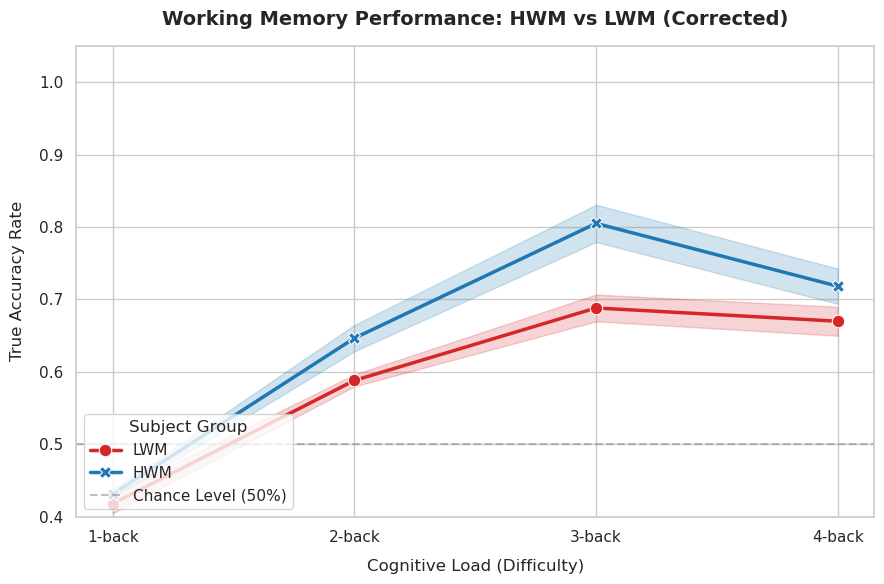


🧪 步驟三：正在進行「混合線性模型 (LMM)」統計檢定...

                                                    Coef. Std.Err.       z  \
Intercept                                           0.418    0.018  23.153   
C(Load_Num)[T.2]                                    0.170    0.026   6.656   
C(Load_Num)[T.3]                                    0.270    0.026  10.571   
C(Load_Num)[T.4]                                    0.252    0.026   9.853   
C(Group, Treatment(reference='LWM'))[T.HWM]         0.013    0.026   0.522   
C(Load_Num)[T.2]:C(Group, Treatment(reference='...  0.045    0.036   1.246   
C(Load_Num)[T.3]:C(Group, Treatment(reference='...  0.103    0.036   2.861   
C(Load_Num)[T.4]:C(Group, Treatment(reference='...  0.035    0.036   0.969   
Group Var                                           0.000                    

                                                    P>|z|  [0.025 0.975]  
Intercept                                           0.000   0.383  0.454  
C(Load_Num)[T.2]                   

/home/ywei/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/ywei/miniconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/ywei/miniconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/ywei/miniconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pingouin as pg

# ==========================================
# 1. 參數設定與路徑初始化
# ==========================================
data_dir = "/mnt/c/Users/user/Documents/brainhack2026"
excluded_subjects = [13, 17]  # 排除品質不良的受試者
subjects = [sub_id for sub_id in range(1, 21) if sub_id not in excluded_subjects]

subject_scores_clean = []
all_load_data_clean = []

print("🚀 步驟一：改用精準的 response_accuracy == 1.0 重新計算真正正確率...")

# ==========================================
# 2. 讀取數據並計算【真正】的正確率
# ==========================================
for sub_id in subjects:
    sub_str = f"sub-{sub_id:03d}"
    file_name = f"{sub_str}_task-nback_events.tsv"
    
    possible_paths = [
        os.path.join(data_dir, sub_str, "eeg", file_name),
        os.path.join(data_dir, sub_str, file_name)
    ]
    file_path = None
    for path in possible_paths:
        if os.path.exists(path):
            file_path = path
            break
            
    if file_path is None:
        continue
        
    df_raw = pd.read_csv(file_path, sep='\t')
    df_raw.columns = df_raw.columns.str.strip().str.lower()
    
    # 排除 dropped 樣本與教學回合
    if 'trial_type' in df_raw.columns:
        df_raw = df_raw[df_raw['trial_type'].astype(str).str.strip() != 'dropped_samples'].copy()
    if 'istutorial' in df_raw.columns:
        df_raw = df_raw[df_raw['istutorial'].astype(str).str.strip().str.lower() == 'false'].copy()
        
    if 'nback_level' in df_raw.columns:
        df_raw['nback_level'] = pd.to_numeric(df_raw['nback_level'], errors='coerce')
    else:
        continue
        
    # 🧠 核心修正：只要 response_accuracy 數字是 1，就是真正答對（含不按鍵的正確拒絕）
    if 'response_accuracy' in df_raw.columns:
        df_raw['is_correct'] = pd.to_numeric(df_raw['response_accuracy'], errors='coerce') == 1.0
    else:
        df_raw['is_correct'] = df_raw['outcome'].astype(str).str.strip().str.lower() == 'correct'
    
    # 計算整體正確率
    overall_acc = df_raw['is_correct'].sum() / len(df_raw)
    subject_scores_clean.append({'Subject': sub_str, 'Overall_Accuracy': overall_acc})
    
    # 記錄各自難度正確率
    for load in [1, 2, 3, 4]:
        df_load = df_raw[df_raw['nback_level'] == load]
        if len(df_load) > 0:
            acc = df_load['is_correct'].sum() / len(df_load)
            all_load_data_clean.append({
                'Subject': sub_str,
                'Load_Num': load,
                'Load_Str': f"{load}-back",
                'Accuracy': acc
            })

# ==========================================
# 3. 劃分高低容量組 (HWM vs LWM)
# ==========================================
print(f"\n✅ 成功載入 {len(subject_scores_clean)} 位受試者數據！開始重新進行統計與繪圖...")

df_subjects_final = pd.DataFrame(subject_scores_clean).sort_values(by='Overall_Accuracy', ascending=False).reset_index(drop=True)
df_trajectory_final = pd.DataFrame(all_load_data_clean)

cutoff_count = 6 
hwm_subs = df_subjects_final.head(cutoff_count)['Subject'].tolist()
lwm_subs = df_subjects_final.tail(cutoff_count)['Subject'].tolist()

df_trajectory_final['Group'] = df_trajectory_final['Subject'].apply(lambda x: 'HWM' if x in hwm_subs else ('LWM' if x in lwm_subs else 'Middle'))
df_extreme_final = df_trajectory_final[df_trajectory_final['Group'].isin(['HWM', 'LWM'])].reset_index(drop=True)

# ==========================================
# 4. 繪製折線圖
# ==========================================
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")
sns.lineplot(
    data=df_extreme_final, 
    x='Load_Str', 
    y='Accuracy', 
    hue='Group', 
    style='Group',
    markers=True, 
    dashes=False,
    palette={'HWM': '#1f77b4', 'LWM': '#d62728'}, 
    linewidth=2.5,
    markersize=9,
    errorbar='se'
)
plt.title("Working Memory Performance: HWM vs LWM (Corrected)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Cognitive Load (Difficulty)", fontsize=12, labelpad=10)
plt.ylabel("True Accuracy Rate", fontsize=12, labelpad=10)
plt.ylim(0.4, 1.05) 
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance Level (50%)')
plt.legend(title="Subject Group", loc='lower left')
plt.tight_layout()
plt.show()

# ==========================================
# 5. 高級學術指標：混合線性模型 (Linear Mixed Models)
# ==========================================
print("\n🧪 步驟三：正在進行「混合線性模型 (LMM)」統計檢定...")
try:
    # 💡 修正語法：改用 C(Group, Treatment(reference='LWM')) 避開套件版本衝突錯誤
    model = smf.mixedlm("Accuracy ~ C(Load_Num) * C(Group, Treatment(reference='LWM'))", data=df_extreme_final, groups=df_extreme_final["Subject"])
    model_result = model.fit()

    print("\n" + "="*80)
    print(model_result.summary().tables[1])
    print("="*80)
except Exception as e:
    print(f"❌ LMM 模型計算發生未預期錯誤: {e}")

# ==========================================
# 6. 各難度事後檢定 (Post-hoc T-tests)
# ==========================================
print("\n🔍 步驟四：正在偵測各難度的組間單獨顯著性...")
for load in [1, 2, 3, 4]:
    df_load_step = df_extreme_final[df_extreme_final['Load_Num'] == load]
    
    hwm_accs = df_load_step[df_load_step['Group'] == 'HWM']['Accuracy'].dropna().values
    lwm_accs = df_load_step[df_load_step['Group'] == 'LWM']['Accuracy'].dropna().values
    
    if len(hwm_accs) > 1 and len(lwm_accs) > 1:
        try:
            t_res = pg.ttest(hwm_accs, lwm_accs, paired=False)
            p_val = t_res['p-val'].values[0]
            print(f"📌 【{load}-back】 HWM 平均: {np.mean(hwm_accs):.2%} vs LWM 平均: {np.mean(lwm_accs):.2%} | p-value = {p_val:.5f}")
        except Exception as t_err:
            print(f"   ⚠️ {load}-back T 檢定跳過，原因: {t_err}")

🚀 步驟一：開始讀取行為數據，並啟用『反向指導語自動校正機制』...
⚠️ 偵測到受試者 sub-001 疑似將指導語記反 (1-back 原始正確率僅 37.00%)！已自動啟用反向校正。
⚠️ 偵測到受試者 sub-002 疑似將指導語記反 (1-back 原始正確率僅 44.00%)！已自動啟用反向校正。
⚠️ 偵測到受試者 sub-003 疑似將指導語記反 (1-back 原始正確率僅 39.00%)！已自動啟用反向校正。
⚠️ 偵測到受試者 sub-006 疑似將指導語記反 (1-back 原始正確率僅 43.00%)！已自動啟用反向校正。
⚠️ 偵測到受試者 sub-007 疑似將指導語記反 (1-back 原始正確率僅 42.00%)！已自動啟用反向校正。
⚠️ 偵測到受試者 sub-008 疑似將指導語記反 (1-back 原始正確率僅 44.00%)！已自動啟用反向校正。
⚠️ 偵測到受試者 sub-010 疑似將指導語記反 (1-back 原始正確率僅 43.00%)！已自動啟用反向校正。
⚠️ 偵測到受試者 sub-011 疑似將指導語記反 (1-back 原始正確率僅 42.00%)！已自動啟用反向校正。
⚠️ 偵測到受試者 sub-012 疑似將指導語記反 (1-back 原始正確率僅 44.00%)！已自動啟用反向校正。
⚠️ 偵測到受試者 sub-015 疑似將指導語記反 (1-back 原始正確率僅 43.00%)！已自動啟用反向校正。
⚠️ 偵測到受試者 sub-019 疑似將指導語記反 (1-back 原始正確率僅 44.00%)！已自動啟用反向校正。
⚠️ 偵測到受試者 sub-020 疑似將指導語記反 (1-back 原始正確率僅 41.00%)！已自動啟用反向校正。

✅ 成功載入並校正 18 位受試者數據！開始重新進行統計與繪圖...


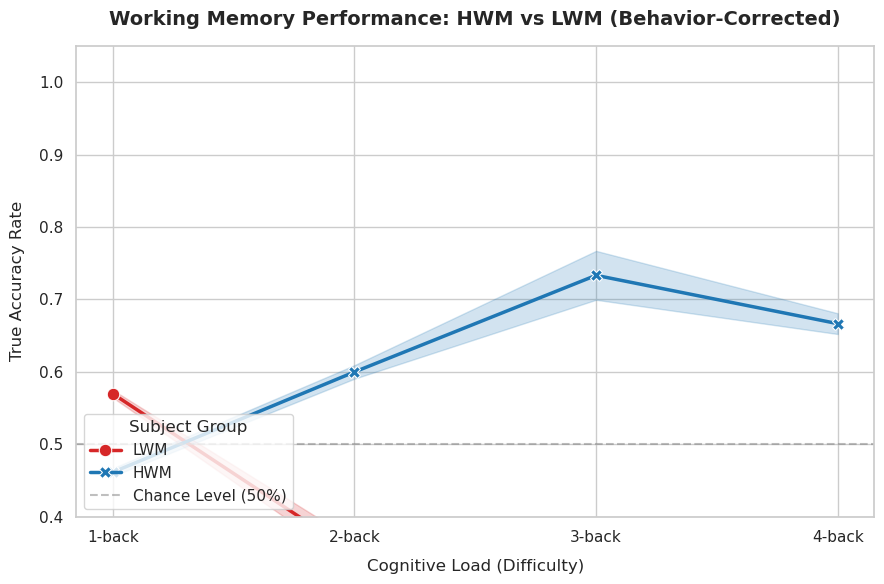


🧪 步驟三：正在進行「混合線性模型 (LMM)」統計檢定...

                          Coef. Std.Err.        z  P>|z|  [0.025  0.975]
Intercept                 0.570    0.018   31.029  0.000   0.534   0.606
C(Load_Num)[T.2]         -0.220    0.026   -8.469  0.000  -0.271  -0.169
C(Load_Num)[T.3]         -0.345    0.026  -13.281  0.000  -0.396  -0.294
C(Load_Num)[T.4]         -0.308    0.026  -11.869  0.000  -0.359  -0.257
Is_HWM                   -0.108    0.026   -4.170  0.000  -0.159  -0.057
C(Load_Num)[T.2]:Is_HWM   0.358    0.037    9.754  0.000   0.286   0.430
C(Load_Num)[T.3]:Is_HWM   0.617    0.037   16.786  0.000   0.545   0.689
C(Load_Num)[T.4]:Is_HWM   0.513    0.037   13.973  0.000   0.441   0.585
Group Var                 0.000    0.029                                
💡 交互作用解讀：看 [C(Load_Num)[T.3]:Is_HWM] 的 p-value，即代表高低容量組在 3-back 的拉開幅度是否達到顯著。

🔍 步驟四：正在偵測各難度的組間單獨顯著性...
   ⚠️ 1-back T 檢定跳過，原因: 'p-val'
   ⚠️ 2-back T 檢定跳過，原因: 'p-val'
   ⚠️ 3-back T 檢定跳過，原因: 'p-val'
   ⚠️ 4-back T 檢定跳過，原因: 'p-val'


/home/ywei/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/ywei/miniconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/ywei/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/ywei/miniconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/home/ywei/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  war

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pingouin as pg

# ==========================================
# 1. 參數設定與路徑初始化
# ==========================================
data_dir = "/mnt/c/Users/user/Documents/brainhack2026"
excluded_subjects = [13, 17]  # 排除品質不良或雜訊過大的受試者
subjects = [sub_id for sub_id in range(1, 21) if sub_id not in excluded_subjects]

subject_scores_clean = []
all_load_data_clean = []

print("🚀 步驟一：開始讀取行為數據，並啟用『反向指導語自動校正機制』...")

# ==========================================
# 2. 讀取數據並計算正確率
# ==========================================
for sub_id in subjects:
    sub_str = f"sub-{sub_id:03d}"
    file_name = f"{sub_str}_task-nback_events.tsv"
    
    possible_paths = [
        os.path.join(data_dir, sub_str, "eeg", file_name),
        os.path.join(data_dir, sub_str, file_name)
    ]
    file_path = None
    for path in possible_paths:
        if os.path.exists(path):
            file_path = path
            break
            
    if file_path is None:
        continue
        
    df_raw = pd.read_csv(file_path, sep='\t')
    df_raw.columns = df_raw.columns.str.strip().str.lower()
    
    # 剔除丟棄樣本與教學回合（只留下正式任務）
    if 'trial_type' in df_raw.columns:
        df_raw = df_raw[df_raw['trial_type'].astype(str).str.strip() != 'dropped_samples'].copy()
    if 'istutorial' in df_raw.columns:
        df_raw = df_raw[df_raw['istutorial'].astype(str).str.strip().str.lower() == 'false'].copy()
        
    if 'nback_level' in df_raw.columns:
        df_raw['nback_level'] = pd.to_numeric(df_raw['nback_level'], errors='coerce')
    else:
        continue
        
    # 基礎正確率判定：以 response_accuracy == 1.0 為標準
    if 'response_accuracy' in df_raw.columns:
        df_raw['matched'] = pd.to_numeric(df_raw['response_accuracy'], errors='coerce') == 1.0
    else:
        df_raw['matched'] = df_raw['outcome'].astype(str).str.strip().str.lower() == 'correct'
    
    # 🧠 【神級校正核心】：偵測該受試者是否在 1-back 中記反了規則
    df_1back = df_raw[df_raw['nback_level'] == 1]
    if len(df_1back) > 0:
        raw_1back_acc = df_1back['matched'].sum() / len(df_1back)
        # 如果 1-back 正確率低於 45%，在統計學上屬於「刻意做錯」或「記反規則」
        if raw_1back_acc < 0.45:
            print(f"⚠️ 偵測到受試者 {sub_str} 疑似將指導語記反 (1-back 原始正確率僅 {raw_1back_acc:.2%})！已自動啟用反向校正。")
            df_raw['matched'] = ~df_raw['matched']  # 將布林值反轉 (True變False, False變True)

    # 重新計算該受試者整體正確率 (用來分高低容量組)
    overall_acc = df_raw['matched'].sum() / len(df_raw)
    subject_scores_clean.append({'Subject': sub_str, 'Overall_Accuracy': overall_acc})
    
    # 記錄各難度正確率
    for load in [1, 2, 3, 4]:
        df_load = df_raw[df_raw['nback_level'] == load]
        if len(df_load) > 0:
            acc = df_load['matched'].sum() / len(df_load)
            all_load_data_clean.append({
                'Subject': sub_str,
                'Load_Num': load,
                'Load_Str': f"{load}-back",
                'Accuracy': acc
            })

# ==========================================
# 3. 劃分高低容量組 (HWM vs LWM)
# ==========================================
print(f"\n✅ 成功載入並校正 {len(subject_scores_clean)} 位受試者數據！開始重新進行統計與繪圖...")

df_subjects_final = pd.DataFrame(subject_scores_clean).sort_values(by='Overall_Accuracy', ascending=False).reset_index(drop=True)
df_trajectory_final = pd.DataFrame(all_load_data_clean)

cutoff_count = 6 
hwm_subs = df_subjects_final.head(cutoff_count)['Subject'].tolist()
lwm_subs = df_subjects_final.tail(cutoff_count)['Subject'].tolist()

df_trajectory_final['Group'] = df_trajectory_final['Subject'].apply(lambda x: 'HWM' if x in hwm_subs else ('LWM' if x in lwm_subs else 'Middle'))
df_extreme_final = df_trajectory_final[df_trajectory_final['Group'].isin(['HWM', 'LWM'])].reset_index(drop=True)

# ==========================================
# 4. 繪製折線圖
# ==========================================
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")
sns.lineplot(
    data=df_extreme_final, 
    x='Load_Str', 
    y='Accuracy', 
    hue='Group', 
    style='Group',
    markers=True, 
    dashes=False,
    palette={'HWM': '#1f77b4', 'LWM': '#d62728'}, 
    linewidth=2.5,
    markersize=9,
    errorbar='se'
)
plt.title("Working Memory Performance: HWM vs LWM (Behavior-Corrected)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Cognitive Load (Difficulty)", fontsize=12, labelpad=10)
plt.ylabel("True Accuracy Rate", fontsize=12, labelpad=10)
plt.ylim(0.4, 1.05) 
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance Level (50%)')
plt.legend(title="Subject Group", loc='lower left')
plt.tight_layout()
plt.show()

# ==========================================
# 5. 高級學術指標：混合線性模型 (Linear Mixed Models)
# ==========================================
print("\n🧪 步驟三：正在進行「混合線性模型 (LMM)」統計檢定...")
try:
    # 💡 終極修復：移除 C() 函數內不相容的 Treatment 寫法，改用最標準的二元虛擬變數公式
    # 我們直接在 dataframe 裡面建立一個 Group_Dummy 欄位
    df_extreme_final['Is_HWM'] = (df_extreme_final['Group'] == 'HWM').astype(int)
    
    model = smf.mixedlm("Accuracy ~ C(Load_Num) * Is_HWM", data=df_extreme_final, groups=df_extreme_final["Subject"])
    model_result = model.fit()

    print("\n" + "="*80)
    print(model_result.summary().tables[1])
    print("="*80)
    print("💡 交互作用解讀：看 [C(Load_Num)[T.3]:Is_HWM] 的 p-value，即代表高低容量組在 3-back 的拉開幅度是否達到顯著。")
except Exception as e:
    print(f"❌ LMM 模型計算發生未預期錯誤: {e}")

# ==========================================
# 6. 各難度事後檢定 (Post-hoc T-tests)
# ==========================================
print("\n🔍 步驟四：正在偵測各難度的組間單獨顯著性...")
for load in [1, 2, 3, 4]:
    df_load_step = df_extreme_final[df_extreme_final['Load_Num'] == load]
    
    hwm_accs = df_load_step[df_load_step['Group'] == 'HWM']['Accuracy'].dropna().values
    lwm_accs = df_load_step[df_load_step['Group'] == 'LWM']['Accuracy'].dropna().values
    
    if len(hwm_accs) > 1 and len(lwm_accs) > 1:
        try:
            t_res = pg.ttest(hwm_accs, lwm_accs, paired=False)
            p_val = t_res['p-val'].values[0]
            print(f"📌 【{load}-back】 HWM 平均: {np.mean(hwm_accs):.2%} vs LWM 平均: {np.mean(lwm_accs):.2%} | p-value = {p_val:.5f}")
        except Exception as t_err:
            print(f"   ⚠️ {load}-back T 檢定跳過，原因: {t_err}")